# 45 — Colorado sportsbook source and metric research walkthrough

## 1. Research question, scope, alternatives, and limitations

**Research question.** What Colorado official sportsbook data is available, at what granularity, and how should its native metrics map to the existing `gaming_results` data model?

**Scope.** Methodology research and a notebook prototype only. Official Colorado Department of Revenue / Division of Gaming (Specialized Business Group) monthly Sports Betting Proceeds PDFs and the related HB 21-1292 city reports. Six sampled monthly PDFs spanning at least two years, including July 2026, the latest completed month in the retained archive snapshot (not a rolling latest-month claim).

**This notebook does not:**
- build or register a production collector
- mutate shared metric-contract code, schema, tests, or dependencies
- invent online figures from combined totals
- invent operator brands from statewide reports
- create a substitute SQLite database or claim a database comparison (the DB is never opened, whether or not present locally)
- download the entire historical archive

**Alternatives considered.**
1. Treat Net Sports Betting Proceeds (NSBP) as interchangeable with GGR — **rejected**; statute and the PDF footnotes define them separately.
2. Collect only the HB 21-1292 city NSBP/tax pages — **rejected as primary**; those pages omit handle, payouts, and GGR.
3. Proposed path — inventory the monthly Proceeds PDFs, preserve GGR and NSBP as separate native measures, map channels explicitly, and recommend eligibility without changing the shared contract.

**Limitations (stated up front).**
- Sample of six months cannot prove full-history parser readiness.
- Some archive months are non-text PDFs (require OCR); OCR can misread glyphs.
- May 2020 / June 2020 landing links returned HTTP 404 during this research.
- Publication/revision clocks on the landing page are often unlabeled; unknown timestamps remain unknown.
- Inventory CSV says “operator and statewide”; the public monthly PDFs inspected here do **not** expose operator brands.


## 2. Repeatable setup and explicit offline mode (no database)

**What / why.** Reuse retained official files by default. `DOWNLOAD_ENABLED=False` makes every source-reading path offline, including the archive, launch-month probes, and HB companion. Missing or changed captures fail clearly; no database is opened or replaced.

**First run in a clean checkout.** Set `DOWNLOAD_ENABLED=True` once to acquire the six pinned PDFs plus supporting sources into ignored `data/raw/CO/`. Then set it back to False and rerun. The local capture manifest records actual retrieval clocks; filesystem modification time is never a publication/retrieval clock. A different PDF hash requires source review, not silent acceptance.

**Design choice.** `ENABLE_OCR=False` is the portable default. Image-only months remain visible as deferred, not successfully parsed. Optional OCR requires both external tools and explicit opt-in; this notebook neither installs tools nor changes environment files.

**Inspect.** Versions, source cache mode, tool availability, and the no-database statement. Exact dependency locking and full-history readiness are not claimed.


In [1]:
from __future__ import annotations

import hashlib
import json
import re
import subprocess
import sys
import tempfile
from decimal import Decimal, ROUND_HALF_EVEN
from pathlib import Path
from urllib.parse import unquote, urlparse

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import pdfplumber
from bs4 import BeautifulSoup
from IPython.display import display

ROOT = Path.cwd()
if (ROOT / "gaming" / "src").is_dir():
    ROOT = ROOT / "gaming"
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import (
    http_get,
    http_get_unchecked,
    month_period,
    parse_money,
    project_root,
    save_raw_bytes,
    sha256_bytes,
    utc_now,
)

ROOT = project_root()
RAW_CO = ROOT / "data" / "raw" / "CO"
DATABASE_PATH = ROOT / "data" / "gaming.sqlite"

BROWSER_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    )
}

LANDING_URL = "https://sbg.colorado.gov/sports-betting-monthly-reports"
STATUTE_NSBP = (
    "C.R.S. 44-30-1501(7) / 1 CCR 207-2-1.4(13): net sports betting proceeds "
    "= bets placed excluding free bets, less payments to players, less federal excise taxes."
)

# Explicit acquisition only for missing captures. Existing retained bytes are never refreshed implicitly.
DOWNLOAD_ENABLED = False
ENABLE_OCR = False

# Tolerances fixed a priori from source precision (printed dollars-and-cents).
# Comparisons use Decimal cent quantization so float binary noise is not mistaken
# for a tolerance change. Do not silently widen after failures.
MONEY_TOL_NATIVE = Decimal("0.01")
MONEY_TOL_OCR = MONEY_TOL_NATIVE  # OCR is not a reason to loosen monetary identity checks
PCT_TOL = 0.05  # win% diagnostic only


def as_cents(value) -> Decimal:
    return Decimal(str(value)).quantize(Decimal("0.01"), rounding=ROUND_HALF_EVEN)


def money_close(actual, expected, tol: Decimal) -> bool:
    if actual is None or expected is None or pd.isna(actual) or pd.isna(expected):
        return False
    return abs(as_cents(actual) - as_cents(expected)) <= tol


def git_head() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=ROOT, text=True
        ).strip()
    except (OSError, subprocess.CalledProcessError):
        return "unavailable"


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


print("Repository root:", ROOT)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("pdfplumber:", pdfplumber.__version__)
print("Git HEAD:", git_head())
print("Raw CO directory:", RAW_CO)
print("Existing retained CO files:", len(list(RAW_CO.rglob("*.pdf"))))
print("Production SQLite present:", DATABASE_PATH.exists())
print("No database opened or compared, regardless of file presence; no substitute created.")

# --- OCR toolchain / shared-env declaration probe (read-only; no installs) ---
import shutil

def _tool_version(cmd: list[str]) -> str:
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, check=False)
        lines = (proc.stdout or proc.stderr or "").strip().splitlines()
        return lines[0] if lines else f"exit={proc.returncode}"
    except OSError as exc:
        return f"unavailable ({exc})"


_install = (ROOT.parent / ".cursor" / "install.sh").read_text(encoding="utf-8")
_env = (ROOT.parent / ".cursor" / "environment.json").read_text(encoding="utf-8")
_pyproject = (ROOT.parent / "pyproject.toml").read_text(encoding="utf-8")
_declared_blob = "\n".join([_install, _env, _pyproject]).lower()
OCR_DECLARED_IN_SHARED_ENV = bool(
    re.search(r"poppler|tesseract|pdftoppm|pytesseract|pdf2image", _declared_blob)
)
OCR_BINARIES_PRESENT = (
    shutil.which("pdftoppm") is not None and shutil.which("tesseract") is not None
)
print("\nOCR toolchain probe (read-only; no packages installed by this notebook):")
print("  which pdftoppm:", shutil.which("pdftoppm"))
print("  which tesseract:", shutil.which("tesseract"))
print("  pdftoppm version:", _tool_version(["pdftoppm", "-v"]))
print("  tesseract version:", _tool_version(["tesseract", "--version"]))
print("  OCR declared in .cursor/install.sh|environment.json|pyproject.toml:", OCR_DECLARED_IN_SHARED_ENV)
print("  OCR binaries present on this VM:", OCR_BINARIES_PRESENT)
if OCR_BINARIES_PRESENT and not OCR_DECLARED_IN_SHARED_ENV:
    print(
        "NOTE: binaries exist on this VM but are NOT declared by the shared setup. "
        "A fresh cloud env built only from declared setup cannot rely on OCR."
    )


# One small retained-source cache shared by every download path in this notebook.
pd.set_option("display.max_colwidth", None)
CAPTURE_MANIFEST = RAW_CO / "_review_sources.json"
captures = json.loads(CAPTURE_MANIFEST.read_text(encoding="utf-8")) if CAPTURE_MANIFEST.exists() else {}

def get_source(key, url, expected_sha=None, allow_error=False):
    if key in captures:
        record = captures[key]
        if record["url"] != url:
            raise ValueError(f"Capture URL changed for {key}; review the source, do not overwrite it.")
        path = (ROOT / record["relative_path"]).resolve()
        if not path.is_relative_to(RAW_CO.resolve()):
            raise ValueError("Capture path must remain under data/raw/CO")
        content = path.read_bytes()
        if sha256_bytes(content) != record["source_sha256"]:
            raise ValueError(f"Retained source bytes changed: {key}")
    else:
        if not DOWNLOAD_ENABLED:
            raise FileNotFoundError(f"Missing retained source {key}. Enable DOWNLOAD_ENABLED once, then rerun offline.")
        response = http_get_unchecked(url, headers=BROWSER_HEADERS)
        if not allow_error:
            response.raise_for_status()
        content = response.content
        digest = sha256_bytes(content)
        if expected_sha is not None and digest != expected_sha:
            raise ValueError(f"Official source changed: {key}; expected {expected_sha}, got {digest}. Review before using.")
        retrieved = utc_now()
        filename = Path(unquote(urlparse(url).path)).name or key
        path = save_raw_bytes(ROOT, "CO", content, filename, retrieved_at=retrieved)
        record = dict(url=url, relative_path=path.relative_to(ROOT).as_posix(),
                      source_sha256=digest, retrieved_at_utc=retrieved.isoformat(),
                      http_status=response.status_code)
        captures[key] = record
        CAPTURE_MANIFEST.write_text(json.dumps(captures, indent=2), encoding="utf-8")
    if expected_sha is not None and record["source_sha256"] != expected_sha:
        raise ValueError(f"Wrong reviewed source version for {key}")
    if record["http_status"] != 200 and not allow_error:
        raise ValueError(f"HTTP {record['http_status']} is not a successful source for {key}")
    return content, record


Repository root: C:\Users\Sean\.codex\visualizations\2026\09\04\01a06e74-f0bf-74b1-a889-d69f9e210128\co-review
Python: 3.11.9
pandas: 3.0.5
pdfplumber: 0.11.10
Git HEAD: 968f559b27e7afacd0477bfd383be95b7757bb58
Raw CO directory: C:\Users\Sean\.codex\visualizations\2026\09\04\01a06e74-f0bf-74b1-a889-d69f9e210128\co-review\data\raw\CO
Existing retained CO files: 9
Production SQLite present: False
No database opened or compared, regardless of file presence; no substitute created.

OCR toolchain probe (read-only; no packages installed by this notebook):
  which pdftoppm: C:\Users\Sean\.cache\codex-runtimes\codex-primary-runtime\dependencies\native\poppler\Library\bin\pdftoppm.EXE
  which tesseract: None
  pdftoppm version: pdftoppm version 26.07.0
  tesseract version: unavailable ([WinError 2] The system cannot find the file specified)
  OCR declared in .cursor/install.sh|environment.json|pyproject.toml: False
  OCR binaries present on this VM: False


## 3. Official source inventory and historical coverage

**What.** Read the retained Division of Gaming monthly-reports landing page, list main Proceeds PDFs versus HB 21-1292 city PDFs, and summarize revision labels without downloading every file.

**Why.** Coverage and layout regime must be known before proposing a collector.

**Assumptions.** The landing page HTML is the authoritative public archive index for this research. Link-text revision notes are incomplete; filename tokens like `v2` / `Revised` are additional signals only.

**Inspect.** Counts by series, earliest/latest labels, recorded HTTP probe results for launch months, and later text-extractability notes from the sampled set.


In [2]:
landing_bytes, landing_capture = get_source("landing", LANDING_URL)
landing_html = landing_bytes.decode("utf-8")
landing_sha = landing_capture["source_sha256"]
landing_path = ROOT / landing_capture["relative_path"]
landing_retrieved_at = landing_capture["retrieved_at_utc"]

soup = BeautifulSoup(landing_html, "html.parser")
rows = []
for anchor in soup.find_all("a", href=True):
    label = " ".join(anchor.get_text(" ", strip=True).split())
    href = anchor["href"]
    if not href:
        continue
    if href.startswith("/"):
        href = "https://sbg.colorado.gov" + href
    elif href.startswith("sites/"):
        href = "https://sbg.colorado.gov/" + href
    low = label.lower()
    if not href.lower().endswith(".pdf"):
        continue
    if "hb" in low and "1292" in low:
        series = "hb21_1292_city"
    elif "sports betting" in low and "proceeds" in low:
        series = "monthly_proceeds"
    else:
        series = "other_pdf"
    rows.append(
        {
            "series": series,
            "label": label,
            "url": href,
            "label_mentions_revision": bool(re.search(r"revis|correct", label, flags=re.I)),
            "filename_mentions_revision": bool(
                re.search(r"revis|correct|_v\d|v\.\d", unquote(href), flags=re.I)
            ),
        }
    )

inventory = pd.DataFrame(rows).drop_duplicates(subset=["url", "label"])
display(inventory.groupby("series", dropna=False).size().rename("pdf_links").to_frame())

monthly = inventory.loc[inventory["series"] == "monthly_proceeds"].copy()
display(monthly[["label", "url"]].head(8))
display(monthly[["label", "url"]].tail(8))

print("Landing URL:", LANDING_URL)
print(
    "Landing retrieved_at_utc:",
    landing_retrieved_at,
)
print("Landing relative path:", landing_path.relative_to(ROOT))
print("Landing SHA-256:", landing_sha)
print("Monthly proceeds links:", len(monthly))
print("HB 21-1292 links:", int((inventory["series"] == "hb21_1292_city").sum()))
print("Label-revision flags (monthly):", int(monthly["label_mentions_revision"].sum()))
print(
    "Filename-revision flags (monthly):",
    int(monthly["filename_mentions_revision"].sum()),
)

probe_rows = []
for period, probe_label in [("2020-05", "May 2020 Sports Betting Proceeds Report"),
                             ("2020-06", "June 2020 Sports Betting Proceeds Report")]:
    match = inventory.loc[inventory["label"] == probe_label]
    if len(match) != 1:
        raise ValueError(f"Expected one launch-month URL: {probe_label}")
    content, record = get_source("probe-" + period, match.iloc[0]["url"], allow_error=True)
    probe_rows.append(dict(period=period, **record, pdf_magic=content.startswith(b"%PDF")))
launch_probes = pd.DataFrame(probe_rows)
display(launch_probes[["period", "url", "http_status", "pdf_magic", "retrieved_at_utc"]])
print("Probe statuses are retained observations, not assumptions about current availability.")

# --- Coverage ledger: links vs unique months vs revisions (no full download) ---
MONTH_LABEL = re.compile(
    r"\b(January|February|March|April|May|June|July|August|September|October|November|December)"
    r"\s+(20\d{2})\b",
    flags=re.I,
)
MONTH_NUM = {
    "january": 1, "february": 2, "march": 3, "april": 4, "may": 5, "june": 6,
    "july": 7, "august": 8, "september": 9, "october": 10, "november": 11, "december": 12,
}

def period_from_label(label: str) -> str | None:
    m = MONTH_LABEL.search(label)
    if not m:
        return None
    return f"{int(m.group(2)):04d}-{MONTH_NUM[m.group(1).lower()]:02d}"

monthly = monthly.copy()
monthly["period"] = monthly["label"].map(period_from_label)
monthly["filename_mentions_revision"] = monthly["url"].map(
    lambda u: bool(re.search(r"revis|correct|_v\d|v\.\d", unquote(u), flags=re.I))
)
# tolerate either naming from earlier cell
if "label_mentions_revision" not in monthly.columns:
    monthly["label_mentions_revision"] = monthly["label"].map(
        lambda s: bool(re.search(r"revis|correct", s, flags=re.I))
    )

monthly_with_period = monthly.loc[monthly["period"].notna()].copy()
period_link_counts = (
    monthly_with_period.groupby("period").size().rename("landing_links").reset_index()
)
duplicate_periods = period_link_counts.loc[period_link_counts["landing_links"] > 1].copy()
revisionish = monthly.loc[
    monthly["label_mentions_revision"] | monthly["filename_mentions_revision"]
].copy()

coverage_summary = pd.DataFrame(
    [
        {
            "evidence": "archive_links_discovered_monthly_proceeds",
            "count": int(len(monthly)),
            "means": "Landing-page PDF hrefs only; not all downloaded",
        },
        {
            "evidence": "archive_links_discovered_hb21_1292",
            "count": int((inventory["series"] == "hb21_1292_city").sum()),
            "means": "City NSBP/tax companion PDF links",
        },
        {
            "evidence": "unique_reporting_months_from_labels",
            "count": int(monthly_with_period["period"].nunique()),
            "means": "Distinct YYYY-MM parsed from link labels",
        },
        {
            "evidence": "labels_without_parseable_month",
            "count": int(monthly["period"].isna().sum()),
            "means": "Special/FY/summary PDFs or unlabeled links",
        },
        {
            "evidence": "periods_with_multiple_landing_links",
            "count": int(len(duplicate_periods)),
            "means": "Possible revisions or duplicate postings for same month",
        },
        {
            "evidence": "revisionish_label_or_filename_flags",
            "count": int(len(revisionish)),
            "means": "Revised/Corrected/v2 tokens — not a complete revision clock",
        },
    ]
)
display(coverage_summary)
if not duplicate_periods.empty:
    print("Periods with multiple landing links:")
    display(duplicate_periods.sort_values("period"))
if not revisionish.empty:
    print("Revision-flagged monthly links (sample of flags; clocks still unknown):")
    display(revisionish[["period", "label", "url"]].head(20))
print("Publication/revision timestamps on landing page: UNKNOWN (not inferred).")


,pdf_links
series,
hb21_1292_city,62
monthly_proceeds,76
other_pdf,1


,label,url
0,July 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/75%20Monthly%20Summary%20%28July%20%2726%29.pdf
1,June 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/74%20Monthly%20Summary%20%28June%20%2726%29.pdf
2,May 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/73%20Monthly%20Summary%20%28May%20%2726%29.pdf
3,April 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/72%20Monthly%20Summary%20%28April%20%2726%29.pdf
4,March 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/71%20Monthly%20Summary%20%28March%20%2726%29.pdf
5,February 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/70%20Monthly%20Summary%20%28February%20%2726%29.pdf
6,January 2026 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/69%20Monthly%20Summary%20%28January%20%2726%29.pdf
7,December 2025 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/68%20Monthly%20Summary%20%28December%20%2725%29.pdf


,label,url
69,December 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/08%20Monthly%20Summary%20%28December%20%2720%29%20Revised_0.pdf
70,November 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/07%20Monthly%20Summary%20%28November%20%2720%29%20Revised_0.pdf
71,October 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/06%20Monthly%20Summary%20%28October%20%2720%29%20Revised_0.pdf
72,September 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/05%20Monthly%20Summary%20%28September%20%2720%29%20Revised_0.pdf
73,August 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/04%20Monthly%20Summary%20%28August%20%2720%29%20Revised_0.pdf
74,July 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/03%20Monthly%20Summary%20%28July%20%2720%29%20Revised_0.pdf
75,June 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/02%20Monthly%20Summary%20%28June%20%2720%29%20Revised_0.pdf
76,May 2020 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/01%20Monthly%20Summary%20%28May%20%2720%29%20Revised_0.pdf


Landing URL: https://sbg.colorado.gov/sports-betting-monthly-reports
Landing retrieved_at_utc: 2026-09-05T00:50:45.602729+00:00
Landing relative path: data\raw\CO\2026-09-05\2fbcc3618ce2b9c617c94f07573eb2335f9ece4a97078fbb64bb626c25a4f355_sports_betting_monthly_reports_landing.html
Landing SHA-256: 2fbcc3618ce2b9c617c94f07573eb2335f9ece4a97078fbb64bb626c25a4f355
Monthly proceeds links: 76
HB 21-1292 links: 62
Label-revision flags (monthly): 1
Filename-revision flags (monthly): 21


,period,url,http_status,pdf_magic,retrieved_at_utc
0,2020-05,https://sbg.colorado.gov/sites/sbg/files/01%20Monthly%20Summary%20%28May%20%2720%29%20Revised_0.pdf,404,False,2026-09-05T00:50:45.987127+00:00
1,2020-06,https://sbg.colorado.gov/sites/sbg/files/02%20Monthly%20Summary%20%28June%20%2720%29%20Revised_0.pdf,404,False,2026-09-05T00:50:46.305829+00:00


Probe statuses are retained observations, not assumptions about current availability.


,evidence,count,means
0,archive_links_discovered_monthly_proceeds,76,Landing-page PDF hrefs only; not all downloaded
1,archive_links_discovered_hb21_1292,62,City NSBP/tax companion PDF links
2,unique_reporting_months_from_labels,75,Distinct YYYY-MM parsed from link labels
3,labels_without_parseable_month,1,Special/FY/summary PDFs or unlabeled links
4,periods_with_multiple_landing_links,0,Possible revisions or duplicate postings for same month
5,revisionish_label_or_filename_flags,21,Revised/Corrected/v2 tokens — not a complete revision clock


Revision-flagged monthly links (sample of flags; clocks still unknown):


,period,label,url
40,2023-04,April 2023 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/36%20Monthly%20Summary%20%28April%20%2723%29%20v.2_0.pdf
43,2023-01,January 2023 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/33%20Monthly%20Summary%20%28January%20%2723%29%20v.2.pdf
46,2022-10,October 2022 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/30%20Monthly%20Summary%20%28October%20%2722%29%20v.2.pdf
48,2022-08,August 2022 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/28%20Monthly%20Summary%20%28August%20%2722%29%20v.2_0.pdf
49,2022-07,July 2022 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/27%20Monthly%20Summary%20%28July%20%2722%29%20v.2.pdf
55,2022-02,February 2022 Sports Betting Proceeds Report (Corrected 4/4/2022),https://sbg.colorado.gov/sites/sbg/files/documents/22%20Monthly%20Summary%20%28February%20%2722%29%20Revised%20%281%29.pdf
56,2022-01,January 2022 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/21%20Monthly%20Summary%20%28January%20%2722%29%20Revised%20v.2.pdf
57,2021-12,December 2021 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/20%20Monthly%20Summary%20%28December%20%2721%29%20Revised%20v.2.pdf
61,2021-08,August 2021 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/documents/16%20Monthly%20Summary%20%28August%20%2721%29%20Revised%20v.2.pdf
65,2021-04,April 2021 Sports Betting Proceeds Report,https://sbg.colorado.gov/sites/sbg/files/12%20Monthly%20Summary%20%28April%20%2721%29%20Revised_0.pdf


Publication/revision timestamps on landing page: UNKNOWN (not inferred).


## 4. Definitions (independently verified)

**What.** Record statutory / regulatory definitions beside the PDF footnote language.

**Why.** Gross Gaming Revenue and Net Sports Betting Proceeds are not interchangeable. Mapping into `gross_revenue` versus `net_proceeds` depends on these definitions.

**Assumptions.** PDF footnotes define GGR for the monthly Proceeds report. NSBP follows C.R.S. / 1 CCR 207-2. Tax rate is statutory 10% of NSBP at the licensee calculation stage; statewide aggregates can diverge from 10% when operator-level floors/true-ups exist.

**Inspect.** The definition table and the explicit non-equivalence warning.


In [3]:
definition_rows = pd.DataFrame(
    [
        {
            "native_term": "Gross Wagers / Total Wagers (handle)",
            "published_definition": (
                "Sum of amounts wagered in the reporting month, shown by sport and by "
                "Retail / Online / Total in the Top 10 Sports table."
            ),
            "source": "Monthly Sports Betting Proceeds PDF sport table",
        },
        {
            "native_term": "Payments to Players (payouts)",
            "published_definition": (
                "Amounts paid to players on winning wagers; paired with Total Wagers by sport."
            ),
            "source": "Monthly Sports Betting Proceeds PDF sport table",
        },
        {
            "native_term": "Gross Gaming Revenue (GGR)",
            "published_definition": "Gross Wagers - Payments to Players",
            "source": "PDF footnote on every sampled Proceeds report",
        },
        {
            "native_term": "Free bets / promotional bets",
            "published_definition": (
                "Non-cashable vouchers, coupons, electronic credits or promotions "
                "(1 CCR 207-2-1.4(9)). Excluded when computing NSBP; not printed as a "
                "standalone statewide column on the Proceeds summary."
            ),
            "source": "1 CCR 207-2-1.4(9); implied by NSBP statute",
        },
        {
            "native_term": "Net Sports Betting Proceeds (NSBP)",
            "published_definition": (
                "Total bets placed excluding free bets, less payments to players, "
                "less federal excise taxes paid under federal law."
            ),
            "source": STATUTE_NSBP
            + "; PDF footnote labels NSBP without expanding the formula",
        },
        {
            "native_term": "Sports betting tax",
            "published_definition": (
                "10% of net sports betting proceeds (C.R.S. 44-30-1508). Remitted monthly."
            ),
            "source": "C.R.S. 44-30-1508; 1 CCR 207-2-4",
        },
        {
            "native_term": "Total Win Percentage",
            "published_definition": (
                "Printed retail/online/total percentage on the summary; empirically tracks "
                "GGR / handle when both are available."
            ),
            "source": "Monthly Proceeds PDF summary row",
        },
    ]
)
display(definition_rows)

print("HARD RULE: do not relabel NSBP as GGR, and do not store NSBP into gross_revenue.")
print(
    "HARD RULE: test handle - payouts against reported GGR only when channel and period align."
)


,native_term,published_definition,source
0,Gross Wagers / Total Wagers (handle),"Sum of amounts wagered in the reporting month, shown by sport and by Retail / Online / Total in the Top 10 Sports table.",Monthly Sports Betting Proceeds PDF sport table
1,Payments to Players (payouts),Amounts paid to players on winning wagers; paired with Total Wagers by sport.,Monthly Sports Betting Proceeds PDF sport table
2,Gross Gaming Revenue (GGR),Gross Wagers - Payments to Players,PDF footnote on every sampled Proceeds report
3,Free bets / promotional bets,"Non-cashable vouchers, coupons, electronic credits or promotions (1 CCR 207-2-1.4(9)). Excluded when computing NSBP; not printed as a standalone statewide column on the Proceeds summary.",1 CCR 207-2-1.4(9); implied by NSBP statute
4,Net Sports Betting Proceeds (NSBP),"Total bets placed excluding free bets, less payments to players, less federal excise taxes paid under federal law.","C.R.S. 44-30-1501(7) / 1 CCR 207-2-1.4(13): net sports betting proceeds = bets placed excluding free bets, less payments to players, less federal excise taxes.; PDF footnote labels NSBP without expanding the formula"
5,Sports betting tax,10% of net sports betting proceeds (C.R.S. 44-30-1508). Remitted monthly.,C.R.S. 44-30-1508; 1 CCR 207-2-4
6,Total Win Percentage,Printed retail/online/total percentage on the summary; empirically tracks GGR / handle when both are available.,Monthly Proceeds PDF summary row


HARD RULE: do not relabel NSBP as GGR, and do not store NSBP into gross_revenue.
HARD RULE: test handle - payouts against reported GGR only when channel and period align.


## 5. Select six monthly reports and optional download

**What.** Choose six main-series monthly Proceeds PDFs spanning September 2020 through July 2026, including the snapshot-latest completed month and both text-extractable and OCR-needed layouts. All six source URLs and hashes below are the inspected snapshot. Reuse retained captures offline; acquire missing captures only when `DOWNLOAD_ENABLED` is true. Never overwrite different bytes at the same path.

**Why.** A bounded sample exposes metric mapping, channel structure, and layout regimes without archiving everything.

**Sample design.**

| period | why included |
| --- | --- |
| 2026-07 | snapshot-latest completed month (text layer) |
| 2025-12 | recent month inside the non-text/OCR regime |
| 2024-06 | revised (`v2`) OCR-regime layout |
| 2023-12 | revised OCR-regime layout |
| 2022-09 | text layout near the apparent text→image transition |
| 2020-09 | early revised text layout (May/June 2020 links 404) |

**Inspect.** Exact URLs, UTC retrieval timestamps, relative paths, SHA-256 hashes, page counts, and whether a native text layer exists.


In [4]:
SAMPLE_SPEC = [
    {'period': '2026-07', 'label': 'July 2026 Sports Betting Proceeds Report', 'layout_expectation': 'native_text', 'role': 'snapshot_latest_completed_month', 'url': 'https://sbg.colorado.gov/sites/sbg/files/documents/75%20Monthly%20Summary%20%28July%20%2726%29.pdf', 'source_sha256': 'e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f'},
    {'period': '2025-12', 'label': 'December 2025 Sports Betting Proceeds Report', 'layout_expectation': 'ocr_needed', 'role': 'recent_image_regime', 'url': 'https://sbg.colorado.gov/sites/sbg/files/documents/68%20Monthly%20Summary%20%28December%20%2725%29.pdf', 'source_sha256': 'a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443'},
    {'period': '2024-06', 'label': 'June 2024 Sports Betting Proceeds Report', 'layout_expectation': 'ocr_needed', 'role': 'revised_image_regime', 'url': 'https://sbg.colorado.gov/sites/sbg/files/documents/50%20Monthly%20Summary%20%28June%20%2724%29%20v2.pdf', 'source_sha256': '237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e'},
    {'period': '2023-12', 'label': 'December 2023 Sports betting Proceeds Report', 'layout_expectation': 'ocr_needed', 'role': 'revised_image_regime', 'url': 'https://sbg.colorado.gov/sites/sbg/files/documents/44%20Monthly%20Summary%20%28December%20%2723%29_0.pdf', 'source_sha256': '34df10fe7b297f5a9a0b38ca7761b55787070a54bdf3a9f69ca8bafb80ba0702'},
    {'period': '2022-09', 'label': 'September 2022 Sports Betting Proceeds Report', 'layout_expectation': 'native_text', 'role': 'text_near_transition', 'url': 'https://sbg.colorado.gov/sites/sbg/files/documents/29%20Monthly%20Summary%20%28September%20%2722%29.pdf', 'source_sha256': 'fc49c0d9f2b7e09442a71c1d83ecb4582279a6ff5f5a7bd2109249f9c066b375'},
    {'period': '2020-09', 'label': 'September 2020 Sports Betting Proceeds Report', 'layout_expectation': 'native_text', 'role': 'early_revised_text', 'url': 'https://sbg.colorado.gov/sites/sbg/files/05%20Monthly%20Summary%20%28September%20%2720%29%20Revised_0.pdf', 'source_sha256': 'adb632d2fee1246832c7abac1428480be6ff951aa73471061787b586d2bbab93'}
]

manifest_rows = []
for spec in SAMPLE_SPEC:
    content, record = get_source(spec["period"], spec["url"], spec["source_sha256"])
    if not content.startswith(b"%PDF"):
        raise ValueError(f"Not a PDF: {spec['url']}")
    path = ROOT / record["relative_path"]
    with pdfplumber.open(path) as pdf:
        pages, n_chars = len(pdf.pages), len(pdf.pages[0].chars or [])
        native = bool((pdf.pages[0].extract_text() or "").strip())
    period_start, period_end = month_period(int(spec["period"][:4]), int(spec["period"][5:7]))
    manifest_rows.append(dict(**spec, relative_path=path.relative_to(ROOT).as_posix(),
                             retrieved_at_utc=record["retrieved_at_utc"], bytes=len(content),
                             pages=pages, page1_chars=n_chars, native_text_layer=native,
                             report_period_start=period_start, report_period_end=period_end,
                             publication_timestamp=None))
manifest = pd.DataFrame(manifest_rows)
display(manifest)
assert len(manifest) == manifest["period"].nunique() == 6
span_years = pd.to_datetime(manifest["report_period_end"]).max().year - pd.to_datetime(manifest["report_period_start"]).min().year
assert span_years >= 2
print("Sample range:", manifest.period.min(), "through", manifest.period.max())
print("Activity, actual capture, and unknown publication clocks remain distinct.")


,period,label,layout_expectation,role,url,source_sha256,relative_path,retrieved_at_utc,bytes,pages,page1_chars,native_text_layer,report_period_start,report_period_end,publication_timestamp
0,2026-07,July 2026 Sports Betting Proceeds Report,native_text,snapshot_latest_completed_month,https://sbg.colorado.gov/sites/sbg/files/documents/75%20Monthly%20Summary%20%28July%20%2726%29.pdf,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f_75_Monthly_Summary_July_26_.pdf,2026-09-05T00:41:14.048472Z,118528,2,1689,True,2026-07-01,2026-07-31,None
1,2025-12,December 2025 Sports Betting Proceeds Report,ocr_needed,recent_image_regime,https://sbg.colorado.gov/sites/sbg/files/documents/68%20Monthly%20Summary%20%28December%20%2725%29.pdf,a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443,data/raw/CO/2026-09-05/a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443_68_Monthly_Summary_December_25_.pdf,2026-09-05T00:41:14.626482Z,500474,2,0,False,2025-12-01,2025-12-31,None
2,2024-06,June 2024 Sports Betting Proceeds Report,ocr_needed,revised_image_regime,https://sbg.colorado.gov/sites/sbg/files/documents/50%20Monthly%20Summary%20%28June%20%2724%29%20v2.pdf,237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e_50_Monthly_Summary_June_24_v2.pdf,2026-09-05T00:41:18.548241Z,548853,1,0,False,2024-06-01,2024-06-30,None
3,2023-12,December 2023 Sports betting Proceeds Report,ocr_needed,revised_image_regime,https://sbg.colorado.gov/sites/sbg/files/documents/44%20Monthly%20Summary%20%28December%20%2723%29_0.pdf,34df10fe7b297f5a9a0b38ca7761b55787070a54bdf3a9f69ca8bafb80ba0702,data/raw/CO/2026-09-05/34df10fe7b297f5a9a0b38ca7761b55787070a54bdf3a9f69ca8bafb80ba0702_44_Monthly_Summary_December_23__0.pdf,2026-09-05T00:41:22.495926Z,570854,1,0,False,2023-12-01,2023-12-31,None
4,2022-09,September 2022 Sports Betting Proceeds Report,native_text,text_near_transition,https://sbg.colorado.gov/sites/sbg/files/documents/29%20Monthly%20Summary%20%28September%20%2722%29.pdf,fc49c0d9f2b7e09442a71c1d83ecb4582279a6ff5f5a7bd2109249f9c066b375,data/raw/CO/2026-09-05/fc49c0d9f2b7e09442a71c1d83ecb4582279a6ff5f5a7bd2109249f9c066b375_29_Monthly_Summary_September_22_.pdf,2026-09-05T00:41:26.482721Z,102781,2,1743,True,2022-09-01,2022-09-30,None
5,2020-09,September 2020 Sports Betting Proceeds Report,native_text,early_revised_text,https://sbg.colorado.gov/sites/sbg/files/05%20Monthly%20Summary%20%28September%20%2720%29%20Revised_0.pdf,adb632d2fee1246832c7abac1428480be6ff951aa73471061787b586d2bbab93,data/raw/CO/2026-09-05/adb632d2fee1246832c7abac1428480be6ff951aa73471061787b586d2bbab93_05_Monthly_Summary_September_20_Revised_0.pdf,2026-09-05T00:41:27.109629Z,204510,2,1655,True,2020-09-01,2020-09-30,None


Sample range: 2020-09 through 2026-07
Activity, actual capture, and unknown publication clocks remain distinct.


## 6. Raw source, extraction, and an independently reviewed sign exception

**What.** Inspect page 1 (monthly financials), then extract exactly three summary values and six wager/payout total values. Missing or ambiguous geometry raises; values are not truncated to fit. Image-only files are `ocr_deferred` by default, with null fields retained in the audit.

**Why.** Arithmetic cannot choose signs and then serve as independent validation of those same signs. The previous general parentheses-repair heuristic has been removed.

**Source evidence and choice.** The rendered July 2026 page displays positive Retail/Online GGR and NSBP, but its native text layer encloses those four values in parentheses. The two displayed pages below were visually reviewed by Codex against the official files. September 2020 visibly prints genuine negative Online/Total NSBP. A notebook-only July exception is tied to the exact PDF SHA and expected extracted triples. It records both raw and visually reviewed signs; it does not derive signs from sums or handle minus payouts. Different source bytes or unexpected tokens require renewed review. This is a reviewed source exception, not an unattended production-ready sign rule.

**Inspect.** Rendered pages, original text lines, raw signed values, reviewed values, and extraction status. No visual/manual/OCR values are supplied for the three deferred image-only months. Poppler/Tesseract are optional OCR tools, not required for native extraction or the inline PDF rendering supplied by pdfplumber.


Official page 1 sign evidence: 2026-07 https://sbg.colorado.gov/sites/sbg/files/documents/75%20Monthly%20Summary%20%28July%20%2726%29.pdf e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f


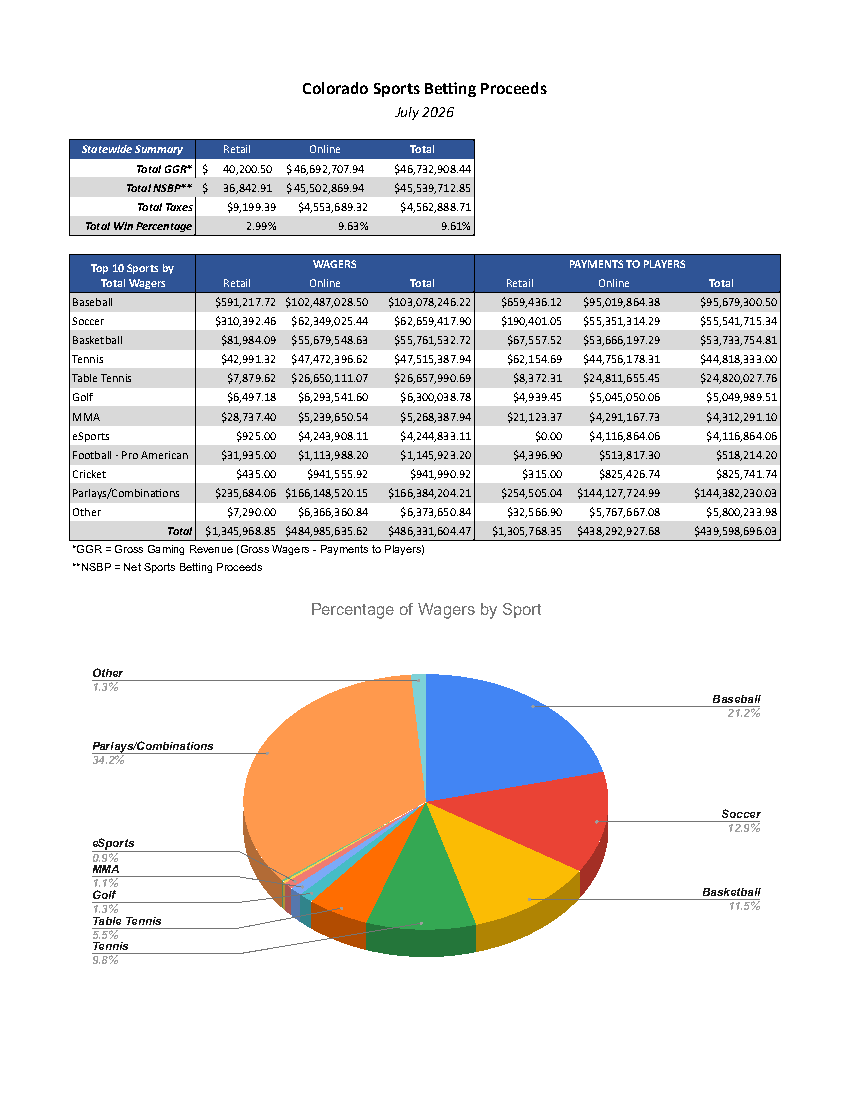

Official page 1 sign evidence: 2020-09 https://sbg.colorado.gov/sites/sbg/files/05%20Monthly%20Summary%20%28September%20%2720%29%20Revised_0.pdf adb632d2fee1246832c7abac1428480be6ff951aa73471061787b586d2bbab93


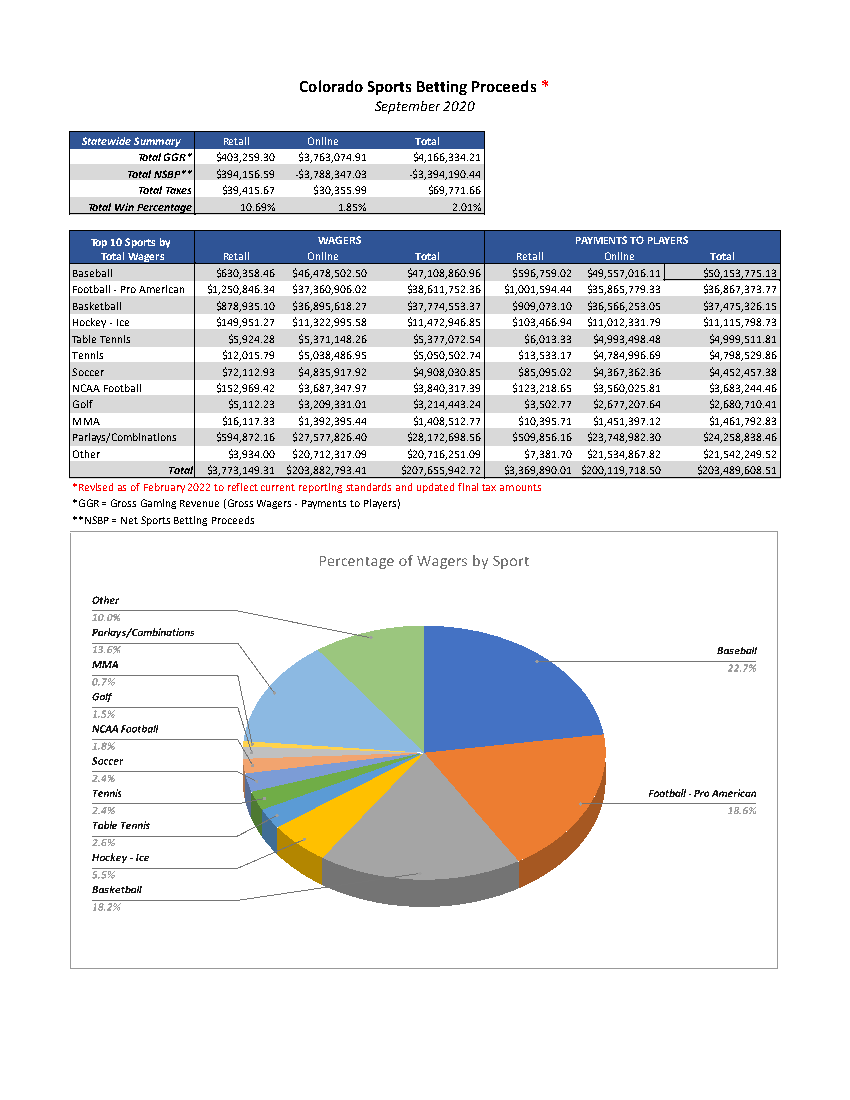

,period,extract_method,preview
0,2026-07,native_text,"Colorado Sports Betting Proceeds\nJuly 2026\nStatewide Summary Retail Online Total\nTotal GGR* ($ 40,200.50) ($46,692,707.94) $46,732,908.44\nTotal NSBP** ($ 36,842.91) ($45,502,869.94) $45,539,712.85\nTotal Taxes $9,199.39 $4,553,689.32 $4,562,888.71\nTotal Win Percentage 2.99% 9.63% 9.61%\n\\nTop 10 Sports by WAGERS PAYMENTS TO PLAYERS\nTotal Wagers Retail Online Total Retail Online Total\nBaseball $591,217.72 $102,487,028.50 $103,078,246.22 $659,436.12 $95,019,864.38 $95,679,300.50\nSoccer $310,392.46 $62,349,025.44 $62,659,417.90 $190,401.05 $55,351,314.29 $55,541,715.34\nBasketball $81,984.09 $55,679,548.63 $55,761,532.72 $67,557.52 $53,666,197.29 $53,733,754.81\nTennis $42,991.32 $47,472,396.62 $47,515,387.94 $62,154.69 $44,756,178.31 $44,818,333.00\nTable Tennis $7,879.62 $26,650,111.07 $26,657,990.69 $8,372.31 $24,811,655.45 $24,820,027.76\nGolf $6,497.18 $6,293,541.60 $6,300,038.78 $4,939.45 $5,045,050.06 $5,049,989.51\nMMA $28,737.40 $5,239,650.54 $5,268,387.94 $21,123.37 $4,291,167.73 $4,312,291.10\neSports $925.00 $4,243,908.11 $4,244,833.11 $0.00 $4,116,864.06 $4,116,864.06"
1,2025-12,ocr_deferred,
2,2024-06,ocr_deferred,
3,2023-12,ocr_deferred,
4,2022-09,native_text,"Colorado Sports Be ng Proceeds\nSeptember 2022\nStatewide Summary Retail Online Total\nTotal GGR* $659,647.30 $50,680,011.95 $51,339,659.25\nTotal NSBP** $648,461.30 $31,022,372.96 $31,670,834.25\nTotal Taxes $39,584.96 $2,949,757.51 $2,989,342.47\nTotal Win Percentage 14.32% 11.37% 11.40%\n\\nTop 10 Sports by WAGERS PAYMENTS TO PLAYERS\nTotal Wagers Retail Online Total Retail Online Total\nFootball - Pro American $1,877,194.14 $143,830,296.12 $145,707,490.26 $1,544,396.62 $128,114,806.00 $129,659,202.62\nBaseball $712,689.36 $82,536,143.22 $83,248,832.58 $738,369.58 $77,814,748.08 $78,553,117.66\nNCAA Football $785,333.60 $51,873,339.62 $52,658,673.22 $648,694.04 $47,833,249.58 $48,481,943.62\nTennis $106,508.94 $32,964,062.10 $33,070,571.04 $149,387.56 $29,813,534.56 $29,962,922.12\nBasketball $20,618.21 $21,579,823.56 $21,600,441.77 $18,019.28 $20,449,628.43 $20,467,647.71\nSoccer $81,134.73 $16,534,699.06 $16,615,833.79 $77,886.04 $14,855,227.92 $14,933,113.96\nTable Tennis $147.00 $5,682,966.86 $5,683,113.86 $12.46 $5,408,270.45 $5,408,282.91\nMMA $33,123.83 $3,455,623.72 $3,488,747.55 $33,904.81 $3,290,640.51 $3,324,545.32"
5,2020-09,native_text,"Colorado Sports Betting Proceeds *\nSeptember 2020\nStatewide Summary Retail Online Total\nTotal GGR* $403,259.30 $3,763,074.91 $4,166,334.21\nTotal NSBP** $394,156.59 -$3,788,347.03 -$3,394,190.44\nTotal Taxes $39,415.67 $30,355.99 $69,771.66\nTotal Win Percentage 10.69% 1.85% 2.01%\n\\nTop 10 Sports by WAGERS PAYMENTS TO PLAYERS\nTotal Wagers Retail Online Total Retail Online Total\nBaseball $630,358.46 $46,478,502.50 $47,108,860.96 $596,759.02 $49,557,016.11 $50,153,775.13\nFootball - Pro American $1,250,846.34 $37,360,906.02 $38,611,752.36 $1,001,594.44 $35,865,779.33 $36,867,373.77\nBasketball $878,935.10 $36,895,618.27 $37,774,553.37 $909,073.10 $36,566,253.05 $37,475,326.15\nHockey - Ice $149,951.27 $11,322,995.58 $11,472,946.85 $103,466.94 $11,012,331.79 $11,115,798.73\nTable Tennis $5,924.28 $5,371,148.26 $5,377,072.54 $6,013.33 $4,993,498.48 $4,999,511.81\nTennis $12,015.79 $5,038,486.95 $5,050,502.74 $13,533.17 $4,784,996.69 $4,798,529.86\nSoccer $72,112.93 $4,835,917.92 $4,908,030.85 $85,095.02 $4,367,362.36 $4,452,457.38\nNCAA Football $152,969.42 $3,687,347.97 $3,840,317.39 $123,218.65 $3,560,025.81 $3,683,244.46"


,0,1,2,3,4,5
period,2026-07,2025-12,2024-06,2023-12,2022-09,2020-09
extract_method,native_text,ocr_deferred,ocr_deferred,ocr_deferred,native_text,native_text
header_period,2026-07,NaN,NaN,NaN,2022-09,2020-09
source_sign_review,True,False,False,False,False,False
units,USD dollars-and-cents as printed,USD dollars-and-cents as printed,USD dollars-and-cents as printed,USD dollars-and-cents as printed,USD dollars-and-cents as printed,USD dollars-and-cents as printed
ggr_retail,40200.5,NaN,NaN,NaN,659647.3,403259.3
ggr_online,46692707.94,NaN,NaN,NaN,50680011.95,3763074.91
ggr_total,46732908.44,NaN,NaN,NaN,51339659.25,4166334.21
nsbp_retail,36842.91,NaN,NaN,NaN,648461.3,394156.59
nsbp_online,45502869.94,NaN,NaN,NaN,31022372.96,-3788347.03


,period,extract_method,source_sha256,ggr_raw_line,nsbp_raw_line,tax_raw_line,wager_payout_raw_line,ggr_raw_values,nsbp_raw_values,ggr_values_used,nsbp_values_used,tax_values_used,wager_payout_values_used,source_sign_review,value_provenance
0,2026-07,native_text,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f,"Total GGR* ($ 40,200.50) ($46,692,707.94) $46,732,908.44","Total NSBP** ($ 36,842.91) ($45,502,869.94) $45,539,712.85","Total Taxes $9,199.39 $4,553,689.32 $4,562,888.71","Total $1,345,968.85 $484,985,635.62 $486,331,604.47 $1,305,768.35 $438,292,927.68 $439,598,696.03","[-40200.5, -46692707.94, 46732908.44]","[-36842.91, -45502869.94, 45539712.85]","[40200.5, 46692707.94, 46732908.44]","[36842.91, 45502869.94, 45539712.85]","[9199.39, 4553689.32, 4562888.71]","[1345968.85, 484985635.62, 486331604.47, 1305768.35, 438292927.68, 439598696.03]",True,native text plus visual sign review
1,2025-12,ocr_deferred,a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443,NaN,NaN,NaN,NaN,None,None,None,None,None,None,False,ocr_deferred
2,2024-06,ocr_deferred,237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e,NaN,NaN,NaN,NaN,None,None,None,None,None,None,False,ocr_deferred
3,2023-12,ocr_deferred,34df10fe7b297f5a9a0b38ca7761b55787070a54bdf3a9f69ca8bafb80ba0702,NaN,NaN,NaN,NaN,None,None,None,None,None,None,False,ocr_deferred
4,2022-09,native_text,fc49c0d9f2b7e09442a71c1d83ecb4582279a6ff5f5a7bd2109249f9c066b375,"Total GGR* $659,647.30 $50,680,011.95 $51,339,659.25","Total NSBP** $648,461.30 $31,022,372.96 $31,670,834.25","Total Taxes $39,584.96 $2,949,757.51 $2,989,342.47","Total $4,607,663.93 $445,624,933.04 $450,232,596.97 $3,948,016.63 $394,944,921.09 $398,892,937.72","[659647.3, 50680011.95, 51339659.25]","[648461.3, 31022372.96, 31670834.25]","[659647.3, 50680011.95, 51339659.25]","[648461.3, 31022372.96, 31670834.25]","[39584.96, 2949757.51, 2989342.47]","[4607663.93, 445624933.04, 450232596.97, 3948016.63, 394944921.09, 398892937.72]",False,native_text
5,2020-09,native_text,adb632d2fee1246832c7abac1428480be6ff951aa73471061787b586d2bbab93,"Total GGR* $403,259.30 $3,763,074.91 $4,166,334.21","Total NSBP** $394,156.59 -$3,788,347.03 -$3,394,190.44","Total Taxes $39,415.67 $30,355.99 $69,771.66","Total $3,773,149.31 $203,882,793.41 $207,655,942.72 $3,369,890.01 $200,119,718.50 $203,489,608.51","[403259.3, 3763074.91, 4166334.21]","[394156.59, -3788347.03, -3394190.44]","[403259.3, 3763074.91, 4166334.21]","[394156.59, -3788347.03, -3394190.44]","[39415.67, 30355.99, 69771.66]","[3773149.31, 203882793.41, 207655942.72, 3369890.01, 200119718.5, 203489608.51]",False,native_text


No signs are chosen by reconciliation. Deferred OCR fields remain null.


In [5]:
def ocr_pdf(path: Path, dpi: int = 250) -> str:
    """Rasterize with poppler pdftoppm, then tesseract CLI.

    Exact commands:
      pdftoppm -png -r {dpi} <pdf> <prefix>
      tesseract <page.png> stdout --psm 6

    No manual transcription of OCR values; native-source sign review is recorded separately.
    """
    if shutil.which("pdftoppm") is None or shutil.which("tesseract") is None:
        raise RuntimeError(
            "OCR requested but pdftoppm/tesseract unavailable. "
            "These tools are not declared in the shared .cursor/install.sh environment."
        )
    with tempfile.TemporaryDirectory() as tmp:
        prefix = Path(tmp) / "page"
        subprocess.check_call(["pdftoppm", "-f", "1", "-singlefile", "-png", "-r", str(dpi), str(path), str(prefix)])
        chunks: list[str] = []
        for image in sorted(Path(tmp).glob("page*.png")):
            chunks.append(
                subprocess.check_output(
                    ["tesseract", str(image), "stdout", "--psm", "6"],
                    text=True,
                )
            )
        return "\n".join(chunks)


def extract_report_text(path: Path) -> tuple[str, str]:
    with pdfplumber.open(path) as pdf:
        native = (pdf.pages[0].extract_text() or "").strip()
    if native:
        return native, "native_text"
    if not ENABLE_OCR:
        return "", "ocr_deferred"
    return ocr_pdf(path), "ocr_tesseract"


MONEY_TOKEN = (
    r"\(\$\s*[\d,]+\.\d{2}\)|"
    r"-\$\s*[\d,]+\.\d{2}|"
    r"\$\s*-[\d,]+\.\d{2}|"
    r"-[\d,]+\.\d{2}|"
    r"\$\s*[\d,]+\.\d{2}|"
    r"[\d,]+\.\d{2}"
)


def parse_money_token(token: str) -> float | None:
    return parse_money(token)


# Visually reviewed July page, not an arithmetic-based sign heuristic.
JULY_REVIEW_SHA = "e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f"
SOURCE_SIGN_REVIEW = {
    "ggr": ([-40200.50, -46692707.94, 46732908.44], [40200.50, 46692707.94, 46732908.44]),
    "nsbp": ([-36842.91, -45502869.94, 45539712.85], [36842.91, 45502869.94, 45539712.85]),
}

def apply_reviewed_signs(values, source_sha, metric):
    if source_sha != JULY_REVIEW_SHA or metric not in SOURCE_SIGN_REVIEW:
        return values, False
    expected_raw, reviewed = SOURCE_SIGN_REVIEW[metric]
    if values != expected_raw:
        raise ValueError(f"July {metric}: native tokens changed; inspect the rendered source again.")
    return reviewed.copy(), True

def find_summary_amounts(text, label_regex):
    lines = [line for line in text.splitlines() if re.search(label_regex, line, flags=re.I)]
    if not text:
        return None, None
    if len(lines) != 1:
        raise ValueError(f"Expected one {label_regex} row, got {len(lines)}")
    values = [parse_money_token(tok) for tok in re.findall(MONEY_TOKEN, lines[0])]
    if len(values) != 3 or any(v is None for v in values):
        raise ValueError(f"Expected exactly three monetary cells: {lines[0]}")
    return values, lines[0]


def find_win_pct(text: str) -> list[float] | None:
    for line in text.splitlines():
        if re.search(r"Total\s+Win\s+Percentage", line, flags=re.I):
            pcts = [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?", line)]
            if len(pcts) == 3:
                return pcts
            raise ValueError(f"Expected three win-percent cells: {line}")
    return None


def find_wager_payout_total(text: str) -> tuple[list[float] | None, str | None]:
    candidates: list[tuple[list[float], str]] = []
    for line in text.splitlines():
        stripped = line.strip()
        if not re.match(r"Total[\s|]", stripped):
            continue
        if any(k in stripped for k in ("GGR", "NSBP", "Taxes", "Win Percentage")):
            continue
        tokens = re.findall(MONEY_TOKEN, stripped)
        values = [parse_money_token(tok) for tok in tokens]
        values = [v for v in values if v is not None]
        if len(values) == 6:
            candidates.append((values, stripped))
        elif tokens:
            raise ValueError(f"Expected six wager/payout total cells: {stripped}")
    if not text:
        return None, None
    if len(candidates) != 1:
        raise ValueError(f"Expected one wager/payout total row, got {len(candidates)}")
    values, raw = candidates[0]
    return values, raw


# Render only inspected financial page 1; images become notebook outputs, not repo files.
for period in ["2026-07", "2020-09"]:
    item = manifest.loc[manifest.period == period].iloc[0]
    print("Official page 1 sign evidence:", period, item.url, item.source_sha256)
    with pdfplumber.open(ROOT / item.relative_path) as pdf:
        display(pdf.pages[0].to_image(resolution=100).original)

raw_previews, parsed_summaries, extraction_audit = [], [], []
for row in manifest.itertuples(index=False):
    text, method = extract_report_text(ROOT / row.relative_path)
    raw_ggr, ggr_line = find_summary_amounts(text, r"Total\s+GGR")
    raw_nsbp, nsbp_line = find_summary_amounts(text, r"Total\s+NSBP")
    taxes, tax_line = find_summary_amounts(text, r"Total\s+Taxes")
    ggr, ggr_reviewed = apply_reviewed_signs(raw_ggr, row.source_sha256, "ggr")
    nsbp, nsbp_reviewed = apply_reviewed_signs(raw_nsbp, row.source_sha256, "nsbp")
    win_pct = find_win_pct(text)
    wager_pay, wager_line = find_wager_payout_total(text)
    header_period = period_from_label(text)
    if method != "ocr_deferred" and header_period != row.period:
        raise ValueError(f"Header period {header_period} differs from manifest {row.period}")
    item = dict(period=row.period, extract_method=method, header_period=header_period,
                source_sign_review=ggr_reviewed or nsbp_reviewed,
                units="USD dollars-and-cents as printed")
    triples = {"ggr": ggr, "nsbp": nsbp, "tax": taxes, "win_pct": win_pct,
               "handle": None if wager_pay is None else wager_pay[:3],
               "payouts": None if wager_pay is None else wager_pay[3:]}
    for metric, values in triples.items():
        for idx, channel in enumerate(["retail", "online", "total"]):
            item[f"{metric}_{channel}"] = None if values is None else values[idx]
    parsed_summaries.append(item)
    extraction_audit.append(dict(period=row.period, extract_method=method,
        source_sha256=row.source_sha256, ggr_raw_line=ggr_line, nsbp_raw_line=nsbp_line,
        tax_raw_line=tax_line, wager_payout_raw_line=wager_line,
        ggr_raw_values=raw_ggr, nsbp_raw_values=raw_nsbp,
        ggr_values_used=ggr, nsbp_values_used=nsbp, tax_values_used=taxes,
        wager_payout_values_used=wager_pay, source_sign_review=ggr_reviewed or nsbp_reviewed,
        value_provenance="native text plus visual sign review" if ggr_reviewed or nsbp_reviewed else method))
    raw_previews.append(dict(period=row.period, extract_method=method, preview="\n".join(text.splitlines()[:18])))

summary = pd.DataFrame(parsed_summaries)
audit_df = pd.DataFrame(extraction_audit)
display(pd.DataFrame(raw_previews))
display(summary.T)
display(audit_df)
print("No signs are chosen by reconciliation. Deferred OCR fields remain null.")


## 7. Explicit extraction of monthly observations

**What.** Melt the parsed statewide summary into one row per period × channel with native measures kept separate.

**Why.** The storage model is period-based. Channels must not be collapsed before mapping.

**Assumptions.** `Total` is an official combined statewide control total, not a substitute for missing online detail. Operator-level rows are unavailable in these PDFs.

**Inspect.** Long monthly audit table. Its 18 rows include nine unparsed channel-placeholders, not 18 successfully parsed observations.


In [6]:
channel_frames = []
for row in summary.itertuples(index=False):
    meta = manifest.loc[manifest["period"] == row.period].iloc[0]
    for channel, suffix in [("retail", "retail"), ("online", "online"), ("combined", "total")]:
        channel_frames.append(
            {
                "period": row.period,
                "period_start": meta["report_period_start"],
                "period_end": meta["report_period_end"],
                "channel": channel,
                "frequency": "monthly",
                "source_sign_review": bool(row.source_sign_review),
                "handle": getattr(row, f"handle_{suffix}"),
                "payouts": getattr(row, f"payouts_{suffix}"),
                "gross_gaming_revenue": getattr(row, f"ggr_{suffix}"),
                "net_sports_betting_proceeds": getattr(row, f"nsbp_{suffix}"),
                "tax": getattr(row, f"tax_{suffix}"),
                "win_pct": getattr(row, f"win_pct_{suffix}"),
                "extract_method": row.extract_method,
                "source_url": meta["url"],
                "source_file": meta["relative_path"],
                "source_sha256": meta["source_sha256"],
                "retrieved_at_utc": meta["retrieved_at_utc"],
                "publication_timestamp": meta["publication_timestamp"],
                "report_status": "retained_review_snapshot",
            }
        )

monthly_obs = pd.DataFrame(channel_frames)
display(monthly_obs)
print("Audit rows:", len(monthly_obs), "(6 months × 3 channels; includes deferred/null rows)")
assert len(monthly_obs) == 18

assert not monthly_obs.duplicated(["period", "channel"]).any()


,period,period_start,period_end,channel,frequency,source_sign_review,handle,payouts,gross_gaming_revenue,net_sports_betting_proceeds,tax,win_pct,extract_method,source_url,source_file,source_sha256,retrieved_at_utc,publication_timestamp,report_status
0,2026-07,2026-07-01,2026-07-31,retail,monthly,True,1.345969e+06,1.305768e+06,40200.50,36842.91,9199.39,2.99,native_text,https://sbg.colorado.gov/sites/sbg/files/documents/75%20Monthly%20Summary%20%28July%20%2726%29.pdf,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f_75_Monthly_Summary_July_26_.pdf,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f,2026-09-05T00:41:14.048472Z,None,retained_review_snapshot
1,2026-07,2026-07-01,2026-07-31,online,monthly,True,4.849856e+08,4.382929e+08,46692707.94,45502869.94,4553689.32,9.63,native_text,https://sbg.colorado.gov/sites/sbg/files/documents/75%20Monthly%20Summary%20%28July%20%2726%29.pdf,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f_75_Monthly_Summary_July_26_.pdf,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f,2026-09-05T00:41:14.048472Z,None,retained_review_snapshot
2,2026-07,2026-07-01,2026-07-31,combined,monthly,True,4.863316e+08,4.395987e+08,46732908.44,45539712.85,4562888.71,9.61,native_text,https://sbg.colorado.gov/sites/sbg/files/documents/75%20Monthly%20Summary%20%28July%20%2726%29.pdf,data/raw/CO/2026-09-05/e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f_75_Monthly_Summary_July_26_.pdf,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f,2026-09-05T00:41:14.048472Z,None,retained_review_snapshot
3,2025-12,2025-12-01,2025-12-31,retail,monthly,False,NaN,NaN,NaN,NaN,NaN,NaN,ocr_deferred,https://sbg.colorado.gov/sites/sbg/files/documents/68%20Monthly%20Summary%20%28December%20%2725%29.pdf,data/raw/CO/2026-09-05/a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443_68_Monthly_Summary_December_25_.pdf,a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443,2026-09-05T00:41:14.626482Z,None,retained_review_snapshot
4,2025-12,2025-12-01,2025-12-31,online,monthly,False,NaN,NaN,NaN,NaN,NaN,NaN,ocr_deferred,https://sbg.colorado.gov/sites/sbg/files/documents/68%20Monthly%20Summary%20%28December%20%2725%29.pdf,data/raw/CO/2026-09-05/a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443_68_Monthly_Summary_December_25_.pdf,a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443,2026-09-05T00:41:14.626482Z,None,retained_review_snapshot
5,2025-12,2025-12-01,2025-12-31,combined,monthly,False,NaN,NaN,NaN,NaN,NaN,NaN,ocr_deferred,https://sbg.colorado.gov/sites/sbg/files/documents/68%20Monthly%20Summary%20%28December%20%2725%29.pdf,data/raw/CO/2026-09-05/a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443_68_Monthly_Summary_December_25_.pdf,a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443,2026-09-05T00:41:14.626482Z,None,retained_review_snapshot
6,2024-06,2024-06-01,2024-06-30,retail,monthly,False,NaN,NaN,NaN,NaN,NaN,NaN,ocr_deferred,https://sbg.colorado.gov/sites/sbg/files/documents/50%20Monthly%20Summary%20%28June%20%2724%29%20v2.pdf,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e_50_Monthly_Summary_June_24_v2.pdf,237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e,2026-09-05T00:41:18.548241Z,None,retained_review_snapshot
7,2024-06,2024-06-01,2024-06-30,online,monthly,False,NaN,NaN,NaN,NaN,NaN,NaN,ocr_deferred,https://sbg.colorado.gov/sites/sbg/files/documents/50%20Monthly%20Summary%20%28June%20%2724%29%20v2.pdf,data/raw/CO/2026-09-05/237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e_50_Monthly_Summary_June_24_v2.pdf,237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e,2026-09-05T00:41:18.548241Z,None,retained_review_snapshot
8,2024-06,2024-06-01,2024-06-30,combined,monthly,False,NaN,NaN,NaN,NaN,NaN,NaN,ocr_deferred,https://sbg.colorado.gov/sites/sbg/files/document

Audit rows: 18 (6 months × 3 channels; includes deferred/null rows)


## 8. Online versus retail versus combined reporting

**What.** Show channel availability and reconcile retail + online against combined totals where all three are published.

**Why.** Project rules forbid estimating online from combined reports and require channel reconciliation when published.

**Assumptions.** Combined == official printed Total column. Retail on these PDFs is on-premises sports betting, not “location-based mobile” in the storage-channel sense.

**Inspect.** Channel coverage matrix and additivity diagnostics.


In [7]:
channel_coverage = (
    monthly_obs.groupby("channel")[
        ["handle", "gross_gaming_revenue", "net_sports_betting_proceeds", "tax"]
    ]
    .apply(lambda frame: frame.notna().mean())
    .rename_axis("metric")
)
display(channel_coverage)

additivity_rows = []
for period, group in monthly_obs.groupby("period"):
    by_ch = group.set_index("channel")
    extract_method = group["extract_method"].iloc[0]
    tol = MONEY_TOL_NATIVE if extract_method == "native_text" else MONEY_TOL_OCR
    for metric in [
        "handle",
        "payouts",
        "gross_gaming_revenue",
        "net_sports_betting_proceeds",
        "tax",
    ]:
        retail = by_ch.loc["retail", metric]
        online = by_ch.loc["online", metric]
        combined = by_ch.loc["combined", metric]
        if pd.isna(retail) or pd.isna(online) or pd.isna(combined):
            status = "missing_inputs"
            diff = pd.NA
        else:
            diff = float(as_cents(retail) + as_cents(online) - as_cents(combined))
            status = "ok" if abs(as_cents(diff)) <= tol else "mismatch"
        additivity_rows.append(
            {
                "period": period,
                "metric": metric,
                "retail": retail,
                "online": online,
                "combined": combined,
                "retail_plus_online_minus_combined": diff,
                "tolerance": float(tol),
                "status": status,
                "extract_method": extract_method,
            }
        )

additivity = pd.DataFrame(additivity_rows)
display(additivity)
print("Additivity mismatches:")
display(additivity.loc[additivity["status"] == "mismatch"])
print(
    "Note: do not estimate online from combined. Online is printed separately on these PDFs."
)


,handle,gross_gaming_revenue,net_sports_betting_proceeds,tax
metric,,,,
combined,0.5,0.5,0.5,0.5
online,0.5,0.5,0.5,0.5
retail,0.5,0.5,0.5,0.5


,period,metric,retail,online,combined,retail_plus_online_minus_combined,tolerance,status,extract_method
0,2020-09,handle,3773149.31,2.038828e+08,2.076559e+08,0.0,0.01,ok,native_text
1,2020-09,payouts,3369890.01,2.001197e+08,2.034896e+08,0.0,0.01,ok,native_text
2,2020-09,gross_gaming_revenue,403259.30,3.763075e+06,4.166334e+06,0.0,0.01,ok,native_text
3,2020-09,net_sports_betting_proceeds,394156.59,-3.788347e+06,-3.394190e+06,0.0,0.01,ok,native_text
4,2020-09,tax,39415.67,3.035599e+04,6.977166e+04,0.0,0.01,ok,native_text
5,2022-09,handle,4607663.93,4.456249e+08,4.502326e+08,0.0,0.01,ok,native_text
6,2022-09,payouts,3948016.63,3.949449e+08,3.988929e+08,0.0,0.01,ok,native_text
7,2022-09,gross_gaming_revenue,659647.30,5.068001e+07,5.133966e+07,0.0,0.01,ok,native_text
8,2022-09,net_sports_betting_proceeds,648461.30,3.102237e+07,3.167083e+07,0.01,0.01,ok,native_text
9,2022-09,tax,39584.96,2.949758e+06,2.989342e+06,0.0,0.01,ok,native_text


Additivity mismatches:


,period,metric,retail,online,combined,retail_plus_online_minus_combined,tolerance,status,extract_method


Note: do not estimate online from combined. Online is printed separately on these PDFs.


## 9. Missingness, duplicates, identifiers, dates, and layout changes

**What.** Flag missing measures, duplicate keys, identifier grain, date clocks, revisions, and the text-versus-OCR layout regime.

**Why.** Collector design hinges on these edge cases more than on the happy path.

**Assumptions.** Archive links may duplicate periods or carry revision labels. Inventory and sample keys are audited separately; replaced historical PDFs cannot be recovered from a single snapshot.

**Inspect.** Quality flags table.


In [8]:
quality_flags = []

# Missingness
missing = monthly_obs.loc[
    monthly_obs[["handle", "payouts", "gross_gaming_revenue", "net_sports_betting_proceeds", "tax"]]
    .isna()
    .any(axis=1)
]
quality_flags.append(
    {
        "topic": "missingness",
        "finding": (
            f"{len(missing)} of {len(monthly_obs)} channel-rows are missing at least one "
            "of handle/payouts/GGR/NSBP/tax in the prototype parse."
        ),
        "detail": missing[["period", "channel", "handle", "payouts", "gross_gaming_revenue"]].to_dict(
            orient="records"
        ),
    }
)

# Duplicate business keys inside the sample
key_cols = ["period", "channel", "source_sha256"]
dupes = monthly_obs.duplicated(key_cols, keep=False)
quality_flags.append(
    {
        "topic": "duplicates",
        "finding": f"Duplicate period/channel/sha rows in sample: {int(dupes.sum())}",
        "detail": [],
    }
)

# Identifiers / grain
quality_flags.append(
    {
        "topic": "identifiers_and_grain",
        "finding": (
            "Public monthly Proceeds PDFs are statewide by channel (Retail/Online/Total) "
            "plus sport breakdown. No operator/brand identifier is published on these pages. "
            "HB 21-1292 companion PDFs add city-level On-Site/Internet NSBP and tax only "
            "(Black Hawk / Central City / Cripple Creek), still not operator brands. "
            "config/state_gaming_source_inventory.csv overstates public granularity as "
            "'operator and statewide' relative to these PDFs."
        ),
        "detail": [],
    }
)

# Dates / clocks
quality_flags.append(
    {
        "topic": "dates_and_clocks",
        "finding": (
            "report_period_start/end = calendar month of wagering activity. "
            "retrieved_at_utc = actual retained capture clock, not this execution clock. "
            "publication_timestamp remains unknown for the sampled files. "
            "Some PDFs foot-note revision months (e.g., 'Revised as of February 2022') "
            "without a precise publication datetime."
        ),
        "detail": manifest[
            ["period", "report_period_start", "report_period_end", "retrieved_at_utc", "publication_timestamp"]
        ].to_dict(orient="records"),
    }
)

# Layout regime
quality_flags.append(
    {
        "topic": "layout_regime_change",
        "finding": (
            "Sampled native-text months: "
            + ", ".join(summary.loc[summary["extract_method"] == "native_text", "period"])
            + ". Sampled OCR-needed months: "
            + ", ".join(summary.loc[summary["extract_method"] != "native_text", "period"])
            + ". Only these six files were checked; transition boundaries are not established. "
            "This is a reporting-artifact regime change, not a metric-definition change by itself."
        ),
        "detail": summary[["period", "extract_method"]].to_dict(orient="records"),
    }
)

# Source gaps
quality_flags.append(
    {
        "topic": "source_gaps",
        "finding": (
            "May 2020 and June 2020 Proceeds links on the landing page returned HTTP 404 "
            "during this research. Launch-month availability is therefore uncertain from "
            "the current public index alone."
        ),
        "detail": [],
    }
)

# False parentheses vs true negatives
quality_flags.append(
    {
        "topic": "sign_and_parentheses",
        "finding": (
            "July 2026 native text wraps retail/online GGR and NSBP in parentheses even though "
            "the rendered official page displays positive values. The SHA-bound review is independent of arithmetic. "
            "September 2020 prints true leading minus signs on online/total NSBP "
            f"(online NSBP={summary.loc[summary['period']=='2020-09', 'nsbp_online'].iloc[0]}). "
            "Negative amounts must be preserved when genuine."
        ),
        "detail": [],
    }
)

display(pd.DataFrame(quality_flags)[["topic", "finding"]])


,topic,finding
0,missingness,9 of 18 channel-rows are missing at least one of handle/payouts/GGR/NSBP/tax in the prototype parse.
1,duplicates,Duplicate period/channel/sha rows in sample: 0
2,identifiers_and_grain,"Public monthly Proceeds PDFs are statewide by channel (Retail/Online/Total) plus sport breakdown. No operator/brand identifier is published on these pages. HB 21-1292 companion PDFs add city-level On-Site/Internet NSBP and tax only (Black Hawk / Central City / Cripple Creek), still not operator brands. config/state_gaming_source_inventory.csv overstates public granularity as 'operator and statewide' relative to these PDFs."
3,dates_and_clocks,"report_period_start/end = calendar month of wagering activity. retrieved_at_utc = actual retained capture clock, not this execution clock. publication_timestamp remains unknown for the sampled files. Some PDFs foot-note revision months (e.g., 'Revised as of February 2022') without a precise publication datetime."
4,layout_regime_change,"Sampled native-text months: 2026-07, 2022-09, 2020-09. Sampled OCR-needed months: 2025-12, 2024-06, 2023-12. Only these six files were checked; transition boundaries are not established. This is a reporting-artifact regime change, not a metric-definition change by itself."
5,source_gaps,May 2020 and June 2020 Proceeds links on the landing page returned HTTP 404 during this research. Launch-month availability is therefore uncertain from the current public index alone.
6,sign_and_parentheses,July 2026 native text wraps retail/online GGR and NSBP in parentheses even though the rendered official page displays positive values. The SHA-bound review is independent of arithmetic. September 2020 prints true leading minus signs on online/total NSBP (online NSBP=-3788347.03). Negative amounts must be preserved when genuine.


## 10. Arithmetic reconciliation and channel-safe proposed scope

**What.** Reconcile handle − payouts to reported GGR by channel. Display **online** handle/payouts/GGR/NSBP/tax with online-only reconciliations. Keep retail/combined in the research stage. Propose production emission for **online + STATEWIDE + official_statewide_total** only.

**Why.** Combined-channel agreement does not validate every online field. Production scope must stay inside existing allowed channels without mapping retail → `location_based_mobile` or changing schema.

**Assumptions.** Tolerances remain a-priori native/OCR cent values. NSBP maps to `net_proceeds`, never `gross_revenue`. Tax is observed only — never inferred as 10% of NSBP.

**Inspect.** Full-channel reconciliation, online-only tables, research vs production proposed rows.


In [9]:
recon_rows = []
for row in monthly_obs.itertuples(index=False):
    tol = MONEY_TOL_NATIVE if row.extract_method == "native_text" else MONEY_TOL_OCR
    derived_ggr = (
        None
        if pd.isna(row.handle) or pd.isna(row.payouts)
        else float(as_cents(row.handle) - as_cents(row.payouts))
    )
    ggr_diff = (
        None
        if derived_ggr is None or pd.isna(row.gross_gaming_revenue)
        else float(as_cents(derived_ggr) - as_cents(row.gross_gaming_revenue))
    )
    ggr_status = (
        "missing_inputs"
        if ggr_diff is None
        else ("ok" if abs(as_cents(ggr_diff)) <= tol else "mismatch")
    )
    implied_win = (
        None
        if pd.isna(row.handle) or float(row.handle) == 0 or pd.isna(row.gross_gaming_revenue)
        else 100.0 * float(row.gross_gaming_revenue) / float(row.handle)
    )
    win_diff = (
        None
        if implied_win is None or pd.isna(row.win_pct)
        else implied_win - float(row.win_pct)
    )
    tax_ratio = (
        None
        if pd.isna(row.tax)
        or pd.isna(row.net_sports_betting_proceeds)
        or float(row.net_sports_betting_proceeds) == 0
        else float(row.tax) / float(row.net_sports_betting_proceeds)
    )
    recon_rows.append(
        {
            "period": row.period,
            "channel": row.channel,
            "extract_method": row.extract_method,
            "tolerance_money": float(tol),
            "handle": row.handle,
            "payouts": row.payouts,
            "reported_ggr": row.gross_gaming_revenue,
            "derived_handle_minus_payouts": derived_ggr,
            "ggr_diff": ggr_diff,
            "ggr_reconcile": ggr_status,
            "reported_win_pct": row.win_pct,
            "implied_ggr_over_handle_pct": implied_win,
            "win_pct_diff_pp": win_diff,
            "nsbp": row.net_sports_betting_proceeds,
            "tax": row.tax,
            "tax_over_nsbp": tax_ratio,
            "tax_ratio_near_10pct": (
                None if tax_ratio is None else abs(tax_ratio - 0.10) <= 0.002
            ),
        }
    )

reconciliation = pd.DataFrame(recon_rows)
display(reconciliation)
print("GGR reconcile status counts (all channels):")
display(reconciliation["ggr_reconcile"].value_counts(dropna=False).to_frame("n"))
print("Exact GGR mismatches (should be empty if parse + definitions align):")
display(reconciliation.loc[reconciliation["ggr_reconcile"] == "mismatch"])

online_fields = (
    monthly_obs.loc[
        monthly_obs["channel"] == "online",
        [
            "period",
            "extract_method",
            "handle",
            "payouts",
            "gross_gaming_revenue",
            "net_sports_betting_proceeds",
            "tax",
        ],
    ]
    .rename(
        columns={
            "gross_gaming_revenue": "ggr",
            "net_sports_betting_proceeds": "nsbp",
        }
    )
    .sort_values("period")
)
online_recon = reconciliation.loc[reconciliation["channel"] == "online"].sort_values("period")
print("Online-channel native fields for all six sample months:")
display(online_fields)
print("Online-channel reconciliation (not inferred from combined):")
display(
    online_recon[
        [
            "period",
            "extract_method",
            "handle",
            "payouts",
            "reported_ggr",
            "derived_handle_minus_payouts",
            "ggr_diff",
            "ggr_reconcile",
            "nsbp",
            "tax",
            "tax_over_nsbp",
            "tax_ratio_near_10pct",
        ]
    ]
)
# Missing/empty comparisons must not turn into a vacuous PASS.
def all_checked_ok(statuses):
    return len(statuses) > 0 and bool(statuses.eq("ok").all())

online_ggr_ok = all_checked_ok(online_recon["ggr_reconcile"])
print("All six sampled online months fully reconciled:", online_ggr_ok)
display(online_recon["ggr_reconcile"].value_counts().to_frame("online_months"))
print(
    "Tax/NSBP is observed only; tax is NOT inferred as 0.10 * NSBP. "
    "Divergences remain unresolved without official operator-level evidence."
)
display(
    online_recon.loc[
        online_recon["tax_ratio_near_10pct"] == False,
        ["period", "nsbp", "tax", "tax_over_nsbp"],
    ]
)

# Research-stage rows retain retail/combined for reconciliation only.
research_rows = []
for row in monthly_obs.itertuples(index=False):
    research_rows.append(
        {
            "stage": "research_reconciliation_only",
            "source_sign_review": row.source_sign_review,
            "jurisdiction": "Colorado",
            "state_code": "CO",
            "vertical": "online_sports_betting",
            "channel": row.channel,
            "operator": "STATEWIDE",
            "row_type": "official_statewide_total",
            "period_start": row.period_start,
            "period_end": row.period_end,
            "frequency": "monthly",
            "handle": row.handle,
            "gross_revenue": row.gross_gaming_revenue,
            "adjusted_revenue": None,
            "taxable_revenue": None,
            "net_proceeds": row.net_sports_betting_proceeds,
            "tax": row.tax,
            "reported_revenue_name": "Gross Gaming Revenue (GGR); NSBP stored separately",
            "source_url": row.source_url,
            "source_file": row.source_file,
            "source_sha256": row.source_sha256,
            "retrieved_at_utc": row.retrieved_at_utc,
            "report_status": row.report_status,
            "mapping_notes": (
                "Research only. Retail is not mapped to location_based_mobile. "
                f"extract_method={row.extract_method}."
            ),
        }
    )
research_df = pd.DataFrame(research_rows)

# Production-proposed scope: online + official_statewide_total + STATEWIDE only.
# Missing or failed months are withheld, never silently counted as good rows.
complete_online = online_fields[["handle", "payouts", "ggr", "nsbp", "tax"]].notna().all(axis=1)
passing_additivity = additivity.groupby("period")["status"].agg(all_checked_ok)
eligible_periods = set(online_fields.loc[complete_online, "period"]) & set(
    online_recon.loc[online_recon.ggr_reconcile.eq("ok"), "period"]
) & set(passing_additivity.loc[passing_additivity].index)
proposed_df = research_df.loc[
    research_df["channel"].eq("online") & research_df["period_start"].str[:7].isin(eligible_periods)
].copy()
proposed_df["stage"] = "review_only_proposed_mapping"
proposed_df["mapping_notes"] = (
    "Production scope: monthly online official_statewide_total with operator=STATEWIDE. "
    "Retail/combined retained only in research. July source sign exception requires explicit review. No writes."
)

print("Research-stage rows (retail/online/combined retained for reconciliation):")
display(
    research_df[
        ["stage", "period_start", "channel", "handle", "gross_revenue", "net_proceeds", "tax"]
    ]
)
print("Review-only proposed rows (complete/reconciled online months only; nothing emitted):")
display(
    proposed_df[
        [
            "stage",
            "state_code",
            "vertical",
            "channel",
            "operator",
            "row_type",
            "period_start",
            "period_end",
            "frequency",
            "handle",
            "gross_revenue",
            "net_proceeds",
            "tax",
            "source_sha256",
            "source_sign_review",
        ]
    ].sort_values("period_start")
)

allowed_channels = {"online", "combined", "location_based_mobile"}
assert set(proposed_df["channel"]).issubset(allowed_channels)
assert (proposed_df["operator"] == "STATEWIDE").all()
assert (proposed_df["row_type"] == "official_statewide_total").all()
assert "retail" not in set(proposed_df["channel"])
print(
    "Production proposal stays inside existing ALLOWED_CHANNELS and uses "
    "operator=STATEWIDE / row_type=official_statewide_total. "
    "No retail→location_based_mobile mapping. No schema changes."
)


,period,channel,extract_method,tolerance_money,handle,payouts,reported_ggr,derived_handle_minus_payouts,ggr_diff,ggr_reconcile,reported_win_pct,implied_ggr_over_handle_pct,win_pct_diff_pp,nsbp,tax,tax_over_nsbp,tax_ratio_near_10pct
0,2026-07,retail,native_text,0.01,1.345969e+06,1.305768e+06,40200.50,40200.50,0.0,ok,2.99,2.986733,-0.003267,36842.91,9199.39,0.249692,False
1,2026-07,online,native_text,0.01,4.849856e+08,4.382929e+08,46692707.94,46692707.94,0.0,ok,9.63,9.627648,-0.002352,45502869.94,4553689.32,0.100075,True
2,2026-07,combined,native_text,0.01,4.863316e+08,4.395987e+08,46732908.44,46732908.44,0.0,ok,9.61,9.609268,-0.000732,45539712.85,4562888.71,0.100196,True
3,2025-12,retail,ocr_deferred,0.01,NaN,NaN,NaN,NaN,NaN,missing_inputs,NaN,NaN,NaN,NaN,NaN,NaN,None
4,2025-12,online,ocr_deferred,0.01,NaN,NaN,NaN,NaN,NaN,missing_inputs,NaN,NaN,NaN,NaN,NaN,NaN,None
5,2025-12,combined,ocr_deferred,0.01,NaN,NaN,NaN,NaN,NaN,missing_inputs,NaN,NaN,NaN,NaN,NaN,NaN,None
6,2024-06,retail,ocr_deferred,0.01,NaN,NaN,NaN,NaN,NaN,missing_inputs,NaN,NaN,NaN,NaN,NaN,NaN,None
7,2024-06,online,ocr_deferred,0.01,NaN,NaN,NaN,NaN,NaN,missing_inputs,NaN,NaN,NaN,NaN,NaN,NaN,None
8,2024-06,combined,ocr_deferred,0.01,NaN,NaN,NaN,NaN,NaN,missing_inputs,NaN,NaN,NaN,NaN,NaN,NaN,None
9,2023-12,retail,ocr_deferred,0.01,NaN,NaN,NaN,NaN,NaN,missing_inputs,NaN,NaN,NaN,NaN,NaN,NaN,None


GGR reconcile status counts (all channels):


,n
ggr_reconcile,
ok,9
missing_inputs,9


Exact GGR mismatches (should be empty if parse + definitions align):


,period,channel,extract_method,tolerance_money,handle,payouts,reported_ggr,derived_handle_minus_payouts,ggr_diff,ggr_reconcile,reported_win_pct,implied_ggr_over_handle_pct,win_pct_diff_pp,nsbp,tax,tax_over_nsbp,tax_ratio_near_10pct


...

Research-stage rows (retail/online/combined retained for reconciliation):


,stage,period_start,channel,handle,gross_revenue,net_proceeds,tax
0,research_reconciliation_only,2026-07-01,retail,1.345969e+06,40200.50,36842.91,9199.39
1,research_reconciliation_only,2026-07-01,online,4.849856e+08,46692707.94,45502869.94,4553689.32
2,research_reconciliation_only,2026-07-01,combined,4.863316e+08,46732908.44,45539712.85,4562888.71
3,research_reconciliation_only,2025-12-01,retail,NaN,NaN,NaN,NaN
4,research_reconciliation_only,2025-12-01,online,NaN,NaN,NaN,NaN
5,research_reconciliation_only,2025-12-01,combined,NaN,NaN,NaN,NaN
6,research_reconciliation_only,2024-06-01,retail,NaN,NaN,NaN,NaN
7,research_reconciliation_only,2024-06-01,online,NaN,NaN,NaN,NaN
8,research_reconciliation_only,2024-06-01,combined,NaN,NaN,NaN,NaN
9,research_reconciliation_only,2023-12-01,retail,NaN,NaN,NaN,NaN


Review-only proposed rows (complete/reconciled online months only; nothing emitted):


,stage,state_code,vertical,channel,operator,row_type,period_start,period_end,frequency,handle,gross_revenue,net_proceeds,tax,source_sha256,source_sign_review
16,review_only_proposed_mapping,CO,online_sports_betting,online,STATEWIDE,official_statewide_total,2020-09-01,2020-09-30,monthly,2.038828e+08,3763074.91,-3788347.03,30355.99,adb632d2fee1246832c7abac1428480be6ff951aa73471061787b586d2bbab93,False
13,review_only_proposed_mapping,CO,online_sports_betting,online,STATEWIDE,official_statewide_total,2022-09-01,2022-09-30,monthly,4.456249e+08,50680011.95,31022372.96,2949757.51,fc49c0d9f2b7e09442a71c1d83ecb4582279a6ff5f5a7bd2109249f9c066b375,False
1,review_only_proposed_mapping,CO,online_sports_betting,online,STATEWIDE,official_statewide_total,2026-07-01,2026-07-31,monthly,4.849856e+08,46692707.94,45502869.94,4553689.32,e3461d7a5d018dd4243a0b552f524d358ac788ff010ef1bb7666bcc56cd5261f,True


Production proposal stays inside existing ALLOWED_CHANNELS and uses operator=STATEWIDE / row_type=official_statewide_total. No retail→location_based_mobile mapping. No schema changes.


## 11. Sample diagnostics, not a continuous time series

**What / why.** Plot observed points with separate USD-billion handle and USD-million revenue axes. Do not draw lines through years with no sampled reports or months with deferred OCR. Missing is not zero.

**Inspect.** Concise dates, genuine September 2020 negative NSBP, and the explicit three-month parse limit. These figures show sample behavior, not growth or full-history trends.


,period,extract_method,handle,gross_gaming_revenue,net_sports_betting_proceeds
1,2026-07,native_text,4.849856e+08,46692707.94,45502869.94
4,2025-12,ocr_deferred,NaN,NaN,NaN
7,2024-06,ocr_deferred,NaN,NaN,NaN
10,2023-12,ocr_deferred,NaN,NaN,NaN
13,2022-09,native_text,4.456249e+08,50680011.95,31022372.96
16,2020-09,native_text,2.038828e+08,3763074.91,-3788347.03


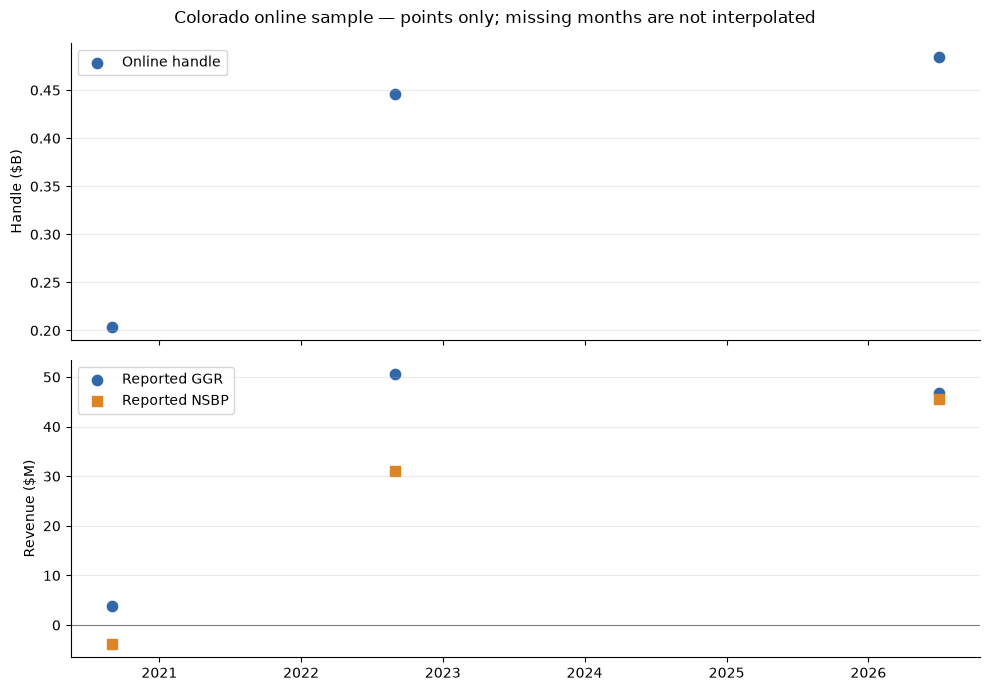

In [10]:
chart = monthly_obs.loc[monthly_obs.channel == "online"].copy()
chart["date"] = pd.to_datetime(chart.period_start)
display(chart[["period", "extract_method", "handle", "gross_gaming_revenue", "net_sports_betting_proceeds"]])
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].scatter(chart.date, chart.handle / 1e9, color="#3268a8", s=55, label="Online handle")
axes[0].set_ylabel("Handle ($B)")
axes[1].scatter(chart.date, chart.gross_gaming_revenue / 1e6, color="#3268a8", s=55, label="Reported GGR")
axes[1].scatter(chart.date, chart.net_sports_betting_proceeds / 1e6, color="#dc8426", marker="s", s=45, label="Reported NSBP")
axes[1].set_ylabel("Revenue ($M)")
axes[1].axhline(0, color="0.5", linewidth=.8)
for ax in axes:
    locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.grid(axis="y", alpha=.25)
    ax.legend(loc="best")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Colorado online sample — points only; missing months are not interpolated")
fig.tight_layout()
plt.show()


## 12. Supporting HB 21-1292 city report (optional cross-check)

**What.** Read the retained July 2026 HB 21-1292 PDF and compare its statewide On-Site/Internet NSBP and tax totals to the July 2026 Proceeds summary.

**Why.** Confirms that the companion series is city-level NSBP/tax, not handle/GGR, and that online/retail NSBP totals can cross-check the main report.

**Assumptions.** HB labels On-Site ≈ Retail and Internet ≈ Online. City rows can be aggregated under HB 21-1292 rules; do not invent operators from cities.

**Inspect.** Parsed HB statewide line versus Proceeds July 2026 retail/online/total NSBP and tax.


In [11]:
hb_label = "July 2026 HB 1292 Monthly Sports Betting Proceeds"
hb_url = inventory.loc[inventory["label"] == hb_label, "url"]
if hb_url.empty:
    raise RuntimeError("July 2026 HB 1292 report not found on landing page")
hb_url = hb_url.iloc[0]
hb_content, hb_capture = get_source("hb-2026-07", hb_url)
if not hb_content.startswith(b"%PDF"):
    raise ValueError("HB companion source is not a PDF")
hb_path = ROOT / hb_capture["relative_path"]
hb_retrieved = hb_capture["retrieved_at_utc"]
with pdfplumber.open(hb_path) as pdf:
    hb_text = "\n".join((page.extract_text() or "") for page in pdf.pages)

print("HB URL:", hb_url)
print("HB retrieved_at_utc:", hb_retrieved)
print("HB relative path:", hb_path.relative_to(ROOT))
print("HB SHA-256:", sha256_file(hb_path))
print(hb_text[:1200])

# Statewide line on HB report
statewide_line = next(
    (line for line in hb_text.splitlines() if line.strip().startswith("Statewide")),
    None,
)
print("Statewide line:", statewide_line)
hb_vals = [parse_money(tok) for tok in re.findall(MONEY_TOKEN, statewide_line or "")]
if len(hb_vals) != 6 or any(v is None for v in hb_vals):
    raise ValueError("HB statewide row must contain exactly six monetary cells")
# Expected geometry: On-Site NSBP, Internet NSBP, Total NSBP, On-Site Tax, Internet Tax, Total Tax
hb_compare = pd.DataFrame(
    [
        {
            "metric": "nsbp_retail_onsite",
            "hb21_1292": None if len(hb_vals) < 1 else hb_vals[0],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "nsbp_retail"].iloc[0],
        },
        {
            "metric": "nsbp_online_internet",
            "hb21_1292": None if len(hb_vals) < 2 else hb_vals[1],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "nsbp_online"].iloc[0],
        },
        {
            "metric": "nsbp_total",
            "hb21_1292": None if len(hb_vals) < 3 else hb_vals[2],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "nsbp_total"].iloc[0],
        },
        {
            "metric": "tax_retail_onsite",
            "hb21_1292": None if len(hb_vals) < 4 else hb_vals[3],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "tax_retail"].iloc[0],
        },
        {
            "metric": "tax_online_internet",
            "hb21_1292": None if len(hb_vals) < 5 else hb_vals[4],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "tax_online"].iloc[0],
        },
        {
            "metric": "tax_total",
            "hb21_1292": None if len(hb_vals) < 6 else hb_vals[5],
            "proceeds_pdf": summary.loc[summary["period"] == "2026-07", "tax_total"].iloc[0],
        },
    ]
)
hb_compare["abs_diff"] = (hb_compare["hb21_1292"] - hb_compare["proceeds_pdf"]).abs()
hb_compare["within_native_tol"] = hb_compare.apply(
    lambda r: money_close(r["hb21_1292"], r["proceeds_pdf"], MONEY_TOL_NATIVE),
    axis=1,
)
display(hb_compare)
print(
    "HB vs Proceeds mismatches at $0.01 native tolerance:",
    int((~hb_compare["within_native_tol"]).sum()),
)


HB URL: https://sbg.colorado.gov/sites/sbg/files/documents/HB%2021-1292%20Report%20July%202026.pdf
HB retrieved_at_utc: 2026-09-05T00:50:46.895822+00:00
HB relative path: data\raw\CO\2026-09-05\ba5c8c12cae289980ac6a03e2c4b580428bb1b9e2e2e93e005689f0376765910_HB_21-1292_Report_July_2026.pdf
HB SHA-256: ba5c8c12cae289980ac6a03e2c4b580428bb1b9e2e2e93e005689f0376765910
Colorado - Division of Gaming
Monthly Sports Betting Proceeds
CURR TOT AMT NSBP TAXES
07/31/26 On-Site Internet Total On-Site Internet Total
Black Hawk $36,842.90 $30,440,405.09 $30,477,247.99 $9,199.39 $3,047,442.83 $3,056,642.22
Central City * $0.00 $0.00 $0.00 $0.00 $0.00 $0.00
Cripple Creek* $0.00 $15,062,464.86 $15,062,464.86 $0.00 $1,506,246.49 $1,506,246.49
Statewide $36,842.90 $45,502,869.95 $45,539,712.85 $9,199.39 $4,553,689.32 $4,562,888.71
Colorado - Division of Gaming
Annual Sports Betting Proceeds
0 0
07/01/2026 - CURR TOT AMT NSBP TAXES 0 0
07/31/2026 On-Site Internet Total On-Site Internet Total
Black Hawk $3

,metric,hb21_1292,proceeds_pdf,abs_diff,within_native_tol
0,nsbp_retail_onsite,36842.90,36842.91,0.01,True
1,nsbp_online_internet,45502869.95,45502869.94,0.01,True
2,nsbp_total,45539712.85,45539712.85,0.00,True
3,tax_retail_onsite,9199.39,9199.39,0.00,True
4,tax_online_internet,4553689.32,4553689.32,0.00,True
5,tax_total,4562888.71,4562888.71,0.00,True


HB vs Proceeds mismatches at $0.01 native tolerance: 0


## 13. OCR reproducibility and non-claims

**What / why.** Separate image-only source availability from successful extraction. Default offline/native execution must complete without OCR tools, but must not claim those files were parsed. An explicitly enabled OCR run uses page 1 only, records tool versions, and still requires the same cent-level reconciliations and independent source inspection.

**Inspect.** Deferred periods, binary availability, shared-environment declarations, and source lines. No dependency installation is performed. Tool presence alone does not prove the declared environment is repeatable.


In [12]:
ocr_periods = manifest.loc[~manifest.native_text_layer, "period"].tolist()
ocr_audit_view = audit_df.loc[audit_df.period.isin(ocr_periods)]
display(ocr_audit_view)
print("Image-only sample periods:", ocr_periods)
print("ENABLE_OCR:", ENABLE_OCR)
print("pdftoppm:", _tool_version(["pdftoppm", "-v"]))
print("tesseract:", _tool_version(["tesseract", "--version"]))
print("Commands if enabled: pdftoppm -f 1 -singlefile -png -r 250 <pdf> <prefix>")
print("                     tesseract <prefix>.png stdout --psm 6")
OCR_REPRO_FROM_DECLARED_ENV = bool(OCR_DECLARED_IN_SHARED_ENV and OCR_BINARIES_PRESENT)
OCR_IMPLEMENTATION_BLOCKER = not OCR_REPRO_FROM_DECLARED_ENV
print("Declared-environment OCR ready:", OCR_REPRO_FROM_DECLARED_ENV)
print("Deferred months in this execution:", int(ocr_audit_view.extract_method.eq("ocr_deferred").sum()))
print("Native July signs use recorded visual source review; no fabricated OCR inputs.")


,period,extract_method,source_sha256,ggr_raw_line,nsbp_raw_line,tax_raw_line,wager_payout_raw_line,ggr_raw_values,nsbp_raw_values,ggr_values_used,nsbp_values_used,tax_values_used,wager_payout_values_used,source_sign_review,value_provenance
1,2025-12,ocr_deferred,a3405fef6f01099849af27df7454035999b77926e899e706e7f1469a50feb443,NaN,NaN,NaN,NaN,None,None,None,None,None,None,False,ocr_deferred
2,2024-06,ocr_deferred,237ecb59053d1b3a2f28db19a0e309dc332335071d46c58d1ccc7ffa9701498e,NaN,NaN,NaN,NaN,None,None,None,None,None,None,False,ocr_deferred
3,2023-12,ocr_deferred,34df10fe7b297f5a9a0b38ca7761b55787070a54bdf3a9f69ca8bafb80ba0702,NaN,NaN,NaN,NaN,None,None,None,None,None,None,False,ocr_deferred


Image-only sample periods: ['2025-12', '2024-06', '2023-12']
ENABLE_OCR: False
pdftoppm: pdftoppm version 26.07.0
tesseract: unavailable ([WinError 2] The system cannot find the file specified)
Commands if enabled: pdftoppm -f 1 -singlefile -png -r 250 <pdf> <prefix>
                     tesseract <prefix>.png stdout --psm 6
Declared-environment OCR ready: False
Deferred months in this execution: 3
Native July signs use recorded visual source review; no fabricated OCR inputs.


## 14. Downstream consolidation and notebook 40 risk (read-only)

**What.** Inspect `variant_gaming.consolidate.build_state_period_revenue` and notebook 40 comparable-state selection. Explain the risk of emitting both `online` and `combined` CO state-month rows.

**Why.** Channel-safe collector scope must anticipate downstream joins before any future combined-row ingestion.

**Assumptions.** Read shared code/notebooks only; do not modify them.

**Inspect.** Channel filters (or lack thereof) and the explicit online-only guard required before combined ingestion.


In [13]:
import json

consolidate_path = ROOT / "src" / "variant_gaming" / "consolidate.py"
nb40_path = ROOT / "notebooks" / "40_sqlite_ggr_analysis.ipynb"
consolidate_text = consolidate_path.read_text(encoding="utf-8")
nb40 = json.loads(nb40_path.read_text(encoding="utf-8"))

print("consolidate.py channel-related lines:")
seen = []
for line in consolidate_text.splitlines():
    if "ONLINE_CHANNELS" in line or (
        "channel" in line and ("combined" in line or "location_based_mobile" in line)
    ):
        s = line.strip()
        if s not in seen:
            seen.append(s)
for line in seen[:30]:
    print(" ", line)

print("\nNotebook 40 comparable-selection snippets:")
for cell in nb40["cells"]:
    src = "".join(cell.get("source", []))
    if "comparable = state_period.loc" not in src:
        continue
    for block in src.split("\n\n"):
        if "comparable = state_period.loc" in block or "valid_ggr = comparable.loc" in block:
            print(block[:1000])
            print("---")

downstream_risk = pd.DataFrame(
    [
        {
            "component": "consolidate.build_state_period_revenue",
            "behavior": (
                "Retains channel in ONLINE_CHANNELS | {combined, location_based_mobile}. "
                "Groups by state/vertical/channel/period, so online and combined for the "
                "same CO month become two state-period rows."
            ),
            "risk_if_co_emits_both": (
                "CO would yield two revenue rows for one month. Combined already includes "
                "online, so channel-agnostic sums double-count Colorado."
            ),
        },
        {
            "component": "notebook 40 comparable cohort",
            "behavior": (
                "Filters vertical==online_sports_betting, frequency==monthly, "
                "revenue_basis==GGR, handle>0. Does not require channel=='online'."
            ),
            "risk_if_co_emits_both": (
                "Both CO online and combined GGR rows can enter valid_ggr. Unique state "
                "lists hide the duplication; month panels/sums may not."
            ),
        },
    ]
)
display(downstream_risk)

print(
    "Explicit guard before any future combined-row ingestion:\n"
    "  1) Initial CO collector emits ONLY channel='online' "
    "(operator='STATEWIDE', row_type='official_statewide_total').\n"
    "  2) Notebook 40 / comparable panels must filter channel=='online' "
    "before including CO in cross-state totals.\n"
    "  3) Do not ingest CO combined rows until that online filter exists downstream.\n"
    "This notebook does not modify notebook 40 or consolidate.py."
)


consolidate.py channel-related lines:
  ONLINE_CHANNELS = {"online"}
  & frame["channel"].isin(ONLINE_CHANNELS | {"combined", "location_based_mobile"})
  & ops["channel"].isin(ONLINE_CHANNELS | {"combined", "location_based_mobile"})

Notebook 40 comparable-selection snippets:
comparable = state_period.loc[
    (state_period["vertical"] == "online_sports_betting")
    & (state_period["frequency"] == "monthly")
    & (state_period["revenue_basis"] == "GGR")
].copy()
comparable["period_start"] = pd.to_datetime(comparable["period_start"])
comparable["handle"] = pd.to_numeric(comparable["handle"], errors="coerce")
comparable["revenue"] = pd.to_numeric(comparable["revenue"], errors="coerce")
---
valid_ggr = comparable.loc[
    comparable["handle"].notna()
    & (comparable["handle"] > 0)
    & comparable["revenue"].notna()
].copy()
---


,component,behavior,risk_if_co_emits_both
0,consolidate.build_state_period_revenue,"Retains channel in ONLINE_CHANNELS | {combined, location_based_mobile}. Groups by state/vertical/channel/period, so online and combined for the same CO month become two state-period rows.","CO would yield two revenue rows for one month. Combined already includes online, so channel-agnostic sums double-count Colorado."
1,notebook 40 comparable cohort,"Filters vertical==online_sports_betting, frequency==monthly, revenue_basis==GGR, handle>0. Does not require channel=='online'.",Both CO online and combined GGR rows can enter valid_ggr. Unique state lists hide the duplication; month panels/sums may not.


Explicit guard before any future combined-row ingestion:
  1) Initial CO collector emits ONLY channel='online' (operator='STATEWIDE', row_type='official_statewide_total').
  2) Notebook 40 / comparable panels must filter channel=='online' before including CO in cross-state totals.
  3) Do not ingest CO combined rows until that online filter exists downstream.
This notebook does not modify notebook 40 or consolidate.py.


## 15. Coverage evidence ledger

**What.** Separate archive links discovered, unique reporting months, successful downloads, and successfully parsed sample months. Keep launch-month 404s and unknown revision clocks visible.

**Inspect.** Evidence table with explicit non-claims.


In [14]:
required_summary = [f"{metric}_{channel}" for metric in ["handle", "payouts", "ggr", "nsbp", "tax"]
                    for channel in ["retail", "online", "total"]]
summary_complete = summary[required_summary].notna().all(axis=1)
complete_periods = set(summary.loc[summary_complete, "period"])
fully_reconciled_periods = complete_periods & eligible_periods
native_parsed = int((summary_complete & summary.extract_method.eq("native_text")).sum())
ocr_parsed = int((summary_complete & summary.extract_method.eq("ocr_tesseract")).sum())
launch_404_count = int(launch_probes.http_status.eq(404).sum())
evidence = pd.DataFrame([
    ("monthly archive links", len(monthly), "Links, not successful downloads"),
    ("unique reporting months from labels", monthly.period.nunique(), "Labels, not verified full coverage"),
    ("retained successful sample PDFs", len(manifest), "Hash-verified bytes; may need OCR"),
    ("completely parsed sample months", int(summary_complete.sum()), f"{native_parsed} native, {ocr_parsed} OCR"),
    ("fully reconciled sample months", len(fully_reconciled_periods), "Complete fields plus channel/GGR reconciliation"),
    ("deferred image-only sample months", int(summary.extract_method.eq("ocr_deferred").sum()), "Not counted as parsed or passed"),
    ("recorded launch-month HTTP 404s", launch_404_count, "Actual retained probe statuses, not a fixed count"),
], columns=["evidence", "count", "meaning"])
display(evidence)
print("Publication/revision clocks remain unknown. No full-history or current-availability claim.")


,evidence,count,meaning
0,monthly archive links,76,"Links, not successful downloads"
1,unique reporting months from labels,75,"Labels, not verified full coverage"
2,retained successful sample PDFs,6,Hash-verified bytes; may need OCR
3,completely parsed sample months,3,"3 native, 0 OCR"
4,fully reconciled sample months,3,Complete fields plus channel/GGR reconciliation
5,deferred image-only sample months,3,Not counted as parsed or passed
6,recorded launch-month HTTP 404s,2,"Actual retained probe statuses, not a fixed count"


Publication/revision clocks remain unknown. No full-history or current-availability claim.


## 16. Validation, edge cases, and readiness

**What / why.** First test failure behavior, then separate successful notebook execution from data coverage. Empty/all-missing comparisons cannot pass. NSBP and GGR may legitimately be equal; correct mapping is tested against their distinct source fields, not numerical inequality.

**Inspect.** Native-only gates versus the incomplete six-month sample; a source-specific sign exception is not a general parser. No output here authorizes ingestion, changes the production DB, or changes cross-state eligibility.


In [15]:
# Small notebook-local regression examples: no shared tests or production code changed.
assert not all_checked_ok(pd.Series([], dtype="object"))
assert not all_checked_ok(pd.Series(["missing_inputs"]))
assert not all_checked_ok(pd.Series(["ok", "missing_inputs"]))
assert all_checked_ok(pd.Series(["ok"]))
assert parse_money_token("($3,788,347.03)") == -3788347.03
assert parse_money_token("-$3,788,347.03") == -3788347.03
assert parse_money_token("$0.00") == 0.0
assert not money_close(None, 0, MONEY_TOL_NATIVE)
assert apply_reviewed_signs([-1., -2., 3.], "unreviewed-source", "ggr") == ([-1., -2., 3.], False)
try:
    apply_reviewed_signs([-1., -2., 3.], JULY_REVIEW_SHA, "ggr")
    raise AssertionError("Unexpected July tokens should require source review")
except ValueError:
    pass
for malformed in ["Total GGR $1.00 $2.00", "Total GGR $1.00 $2.00 $3.00 $4.00",
                  "Total GGR $1.00 $2.00 $3.00\nTotal GGR $1.00 $2.00 $3.00"]:
    try:
        find_summary_amounts(malformed, r"Total\s+GGR")
        raise AssertionError("Missing/extra/duplicate summary cells must fail")
    except ValueError:
        pass

native_periods = set(manifest.loc[manifest.native_text_layer, "period"])
native_recon = reconciliation.loc[reconciliation.period.isin(native_periods)]
native_additivity = additivity.loc[additivity.period.isin(native_periods)]
expected_online = monthly_obs.loc[monthly_obs.channel.eq("online") & monthly_obs.period.isin(eligible_periods)].set_index("period_start").sort_index()
actual_proposed = proposed_df.set_index("period_start").sort_index()
pd.testing.assert_series_equal(actual_proposed.gross_revenue, expected_online.gross_gaming_revenue, check_names=False)
pd.testing.assert_series_equal(actual_proposed.net_proceeds, expected_online.net_sports_betting_proceeds, check_names=False)
assert summary.loc[summary.period.eq("2020-09"), "nsbp_online"].iloc[0] == -3788347.03
assert summary.loc[summary.period.eq("2026-07"), "source_sign_review"].iloc[0]
assert not monthly_obs.duplicated(["period", "channel"]).any()
assert all((ROOT / p).resolve().is_relative_to(RAW_CO.resolve()) for p in manifest.relative_path)
assert set(proposed_df.channel) == {"online"}
assert actual_proposed[["handle", "gross_revenue", "net_proceeds", "tax"]].notna().all().all()
assert all_checked_ok(native_recon.ggr_reconcile)
assert all_checked_ok(native_additivity.status)
assert hb_compare.within_native_tol.all()
assert native_periods.issubset(complete_periods)

validation_df = pd.DataFrame([
    ("native sample fields complete", native_periods.issubset(complete_periods), f"{len(native_periods)} native months"),
    ("native GGR reconciliations", all_checked_ok(native_recon.ggr_reconcile), f"{len(native_recon)} channel rows"),
    ("native channel additivity", all_checked_ok(native_additivity.status), f"{len(native_additivity)} checks"),
    ("all six sample months complete and reconciled", len(fully_reconciled_periods) == len(manifest), "False means incomplete, not execution failure"),
    ("all six online GGR comparisons passed", all_checked_ok(online_recon.ggr_reconcile), "Missing inputs do not pass"),
    ("HB companion matches", bool(hb_compare.within_native_tol.all()), "Six native NSBP/tax cells"),
], columns=["check", "passed", "scope"])
display(validation_df)
display(online_recon[["period", "extract_method", "reported_ggr", "ggr_diff", "ggr_reconcile", "nsbp", "tax"]])
readiness = pd.DataFrame([
    ("mapping", "ready for review", "Separate reported handle, GGR, NSBP, tax; online statewide only"),
    ("native sample", "bounded research prototype", "Three files; July requires the recorded visual sign exception"),
    ("OCR", "deferred / not production-ready", "Opt-in plus declared tools and independent source checks still needed"),
    ("full history", "not ready", "Six sampled files are not full coverage; launch gaps and revisions unresolved"),
], columns=["dimension", "status", "notes"])
display(readiness)
print("Notebook-local edge-case assertions passed. Database never opened or compared.")


,check,passed,scope
0,native sample fields complete,True,3 native months
1,native GGR reconciliations,True,9 channel rows
2,native channel additivity,True,15 checks
3,all six sample months complete and reconciled,False,"False means incomplete, not execution failure"
4,all six online GGR comparisons passed,False,Missing inputs do not pass
5,HB companion matches,True,Six native NSBP/tax cells


,period,extract_method,reported_ggr,ggr_diff,ggr_reconcile,nsbp,tax
16,2020-09,native_text,3763074.91,0.0,ok,-3788347.03,30355.99
13,2022-09,native_text,50680011.95,0.0,ok,31022372.96,2949757.51
10,2023-12,ocr_deferred,NaN,NaN,missing_inputs,NaN,NaN
7,2024-06,ocr_deferred,NaN,NaN,missing_inputs,NaN,NaN
4,2025-12,ocr_deferred,NaN,NaN,missing_inputs,NaN,NaN
1,2026-07,native_text,46692707.94,0.0,ok,45502869.94,4553689.32


,dimension,status,notes
0,mapping,ready for review,"Separate reported handle, GGR, NSBP, tax; online statewide only"
1,native sample,bounded research prototype,Three files; July requires the recorded visual sign exception
2,OCR,deferred / not production-ready,Opt-in plus declared tools and independent source checks still needed
3,full history,not ready,Six sampled files are not full coverage; launch gaps and revisions unresolved


Notebook-local edge-case assertions passed. Database never opened or compared.


### Key findings and validated assumptions

- Official source URLs, bytes, extraction lines and two rendered sign-control pages are available above. Offline mode covers **every** source path and does not change retrieval clocks. In a clean checkout the ignored captures must first be acquired explicitly.
- The six-file sample has **three native-text months and three deferred image-only months** with the default settings. Three native months reconcile; deferred fields are null, never a vacuous pass. The executed coverage table is authoritative if optional OCR is enabled later.
- July 2026 native text signs disagree with its rendered page. The notebook-only, source-SHA-bound exception records the reviewed signs without using arithmetic to choose them. September 2020 genuine negative NSBP is preserved.
- Native mapping preserves GGR separately from NSBP. They need not differ numerically in every observation. Tax is the published value; it is not reconstructed from a rate. Statewide reports cannot create operator identities.
- The online-only proposal contains complete, reconciled sampled months only. Retail and combined are research controls, not additional online observations or production writes.

### Remaining uncertainty / edge cases

- OCR and full-history layout readiness remain unproven. Arithmetic alone does not establish extraction correctness. The sign exception does not generalize to unknown PDFs.
- Launch-month HTTP statuses are actual dated probe records; publication/revision timestamps remain unknown. This snapshot is not fully point-in-time safe and cannot establish survivorship-free historical coverage.
- Tax/NSBP gaps remain unexplained; no tax inversion. No monthly interpolation, synthetic zero fill, or combined-to-online imputation.
- Consolidation retains channels separately, while notebook 40 lacks an explicit online-only filter. Any future combined-row ingestion needs a separate downstream review to prevent double counting. Shared code/notebooks are untouched here.

### Production tests that will be needed

Native-source fixtures with exact reported values; genuine negative and zero money cells; missing/extra/duplicate rows; wrong period and changed source version; independent sign evidence; complete-input gates; channel additivity and GGR identities; unavailable source/OCR handling; provenance and revision separation. The notebook regression examples illustrate failure behavior but do not replace production fixtures.

### Proposed production architecture — later, not implemented

One bounded state parser using existing source/provenance helpers, emitting only monthly online `STATEWIDE` / `official_statewide_total` rows. No new schema, eligibility framework, or general sign-repair engine. Review the native-source exception before promotion; defer OCR until its environment and fixtures are explicitly approved. No database, production, merge, or push activity is performed by this walkthrough.
